<a href="https://colab.research.google.com/github/inigo99/CancerDetection/blob/main/TFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFM Detección de cáncer en mamografías

Íñigo Fernández Barrill

### Introducción

In [1]:
from IPython.display import clear_output

!wget https://unirioja-my.sharepoint.com/:u:/g/personal/infernb_unirioja_es/EbUEV-DxkwdClaZ4O8w6tOQB727Kg1Q9cQzyheUb7NddSA?download=1 -O Mamografias.zip
!unzip Mamografias.zip
clear_output()

In [2]:
!pip install fastai -Uq
!pip install timm -Uq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 18.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.8/236.8 kB 28.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.1 MB/s eta 0:00:00


In [3]:
import fastai
from fastai import *
from fastai.vision import *
from fastai.vision.all import *
from fastai.losses import MSELossFlat, CrossEntropyLossFlat
import timm
import PIL
from torchvision import transforms

path = Path('rsna-breast-cancer-detection_reducido_v2/')
imagesPath = path/'train_images'

In [4]:
import pandas as pd

df = pd.read_csv("rsna-breast-cancer-detection_reducido_v2/train.csv")

In [5]:
dfna = df.dropna(subset=["age", "density"]).copy()

In [6]:
import os
import shutil

p_clean = path/"clean"

if not os.path.isdir(p_clean):
    os.mkdir(p_clean)

for index, row in dfna.iterrows():
    patient = row["patient_id"]
    shutil.copytree(imagesPath/str(patient), p_clean/str(patient), dirs_exist_ok=True)

In [7]:
def cadena(path):
    partes = path.split(os.path.sep)
    return partes[-1][:-4]

def label_func(fname):
    return dfna.loc[dfna['image_id'] == int(cadena(fname.name))]['cancer'].values[0]

In [8]:
dfna = dfna.drop(columns=['site_id', 'implant'])
dfna

,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,density,machine_id,difficult_negative_case
12,10038,1967300488,L,MLO,60.0,0,0,0,1.0,C,216,False
13,10038,2142944869,L,CC,60.0,0,0,0,1.0,C,216,False
14,10038,850559196,R,MLO,60.0,0,0,0,1.0,C,216,False
15,10038,1350492010,R,CC,60.0,0,0,0,1.0,C,216,False
16,10042,102733848,L,CC,51.0,0,0,0,1.0,C,93,False
...,...,...,...,...,...,...,...,...,...,...,...,...
54701,9973,1729524723,R,MLO,43.0,0,0,0,1.0,C,49,False
54702,9989,63473691,L,MLO,60.0,0,0,0,NaN,C,216,False
54703,9989,1078943060,L,CC,60.0,0,0,0,NaN,C,216,False
54704,9989,398038886,R,MLO,60.0,0,0,0,0.0,C,216,True


## Modelos

### Resnet 50

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=256,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_clean, bs=128)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='modelResnet50')
]

In [ ]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

SuggestedLRs(valley=0.004365158267319202)

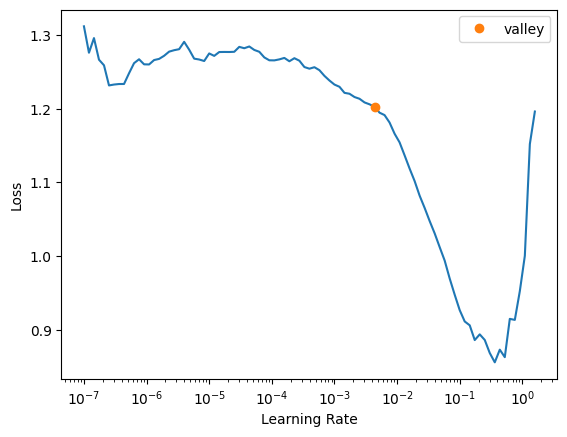

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.584779,0.220679,0.947842,0.017647,0.020979,0.019169,05:03


Better model found at epoch 0 with valid_loss value: 0.22067883610725403.


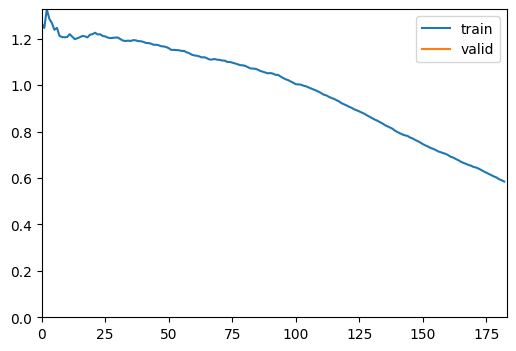

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.196364,0.132173,0.975705,0.000000,0.000000,0.000000,05:25
1,0.133330,0.120084,0.975705,0.000000,0.000000,0.000000,05:02
2,0.115367,0.114995,0.975705,0.000000,0.000000,0.000000,04:59
3,0.108906,0.108490,0.975705,0.000000,0.000000,0.000000,04:55


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.13217325508594513.


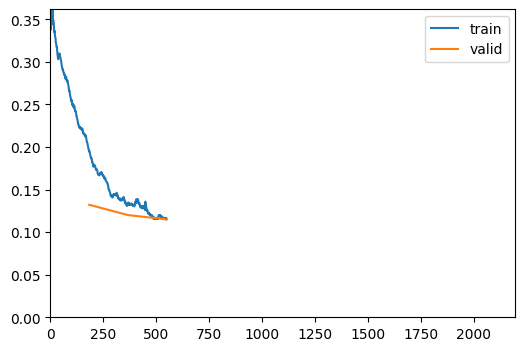

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 1 with valid_loss value: 0.12008360773324966.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 2 with valid_loss value: 0.11499500274658203.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 3 with valid_loss value: 0.10848978161811829.
No improvement since epoch 0: early stopping


In [ ]:
learn.fine_tune(12, base_lr=1e-3)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


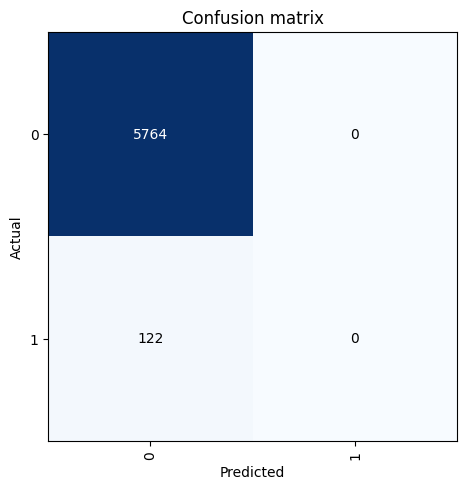

In [ ]:
ClassificationInterpretation.from_learner(learn).plot_confusion_matrix()

### EfficientNet

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=256,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_clean, bs=64)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='efficientNetB3')
]

In [ ]:
learn = vision_learner(dls, efficientnet_b3, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

SuggestedLRs(valley=0.0063095735386013985)

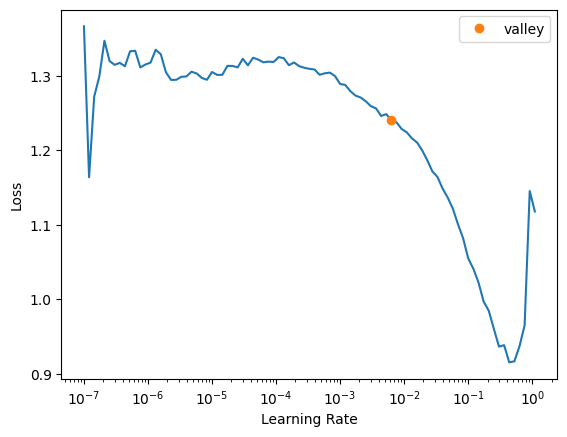

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.181699,0.136927,0.974516,0.000000,0.000000,0.000000,05:42


Better model found at epoch 0 with valid_loss value: 0.1369265466928482.


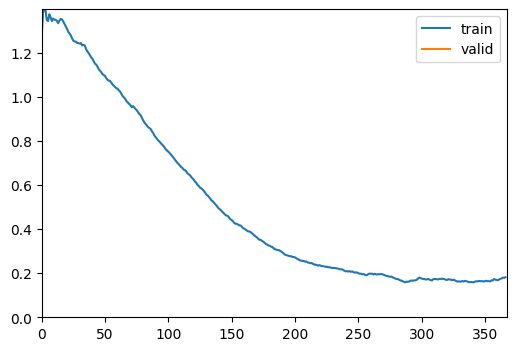

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.129961,0.119991,0.975705,0.000000,0.000000,0.000000,05:21
1,0.117526,0.117836,0.975705,0.000000,0.000000,0.000000,05:17
2,0.137727,0.123567,0.975705,0.000000,0.000000,0.000000,05:16
3,0.111737,0.121650,0.975705,0.000000,0.000000,0.000000,05:20


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.11999120563268661.


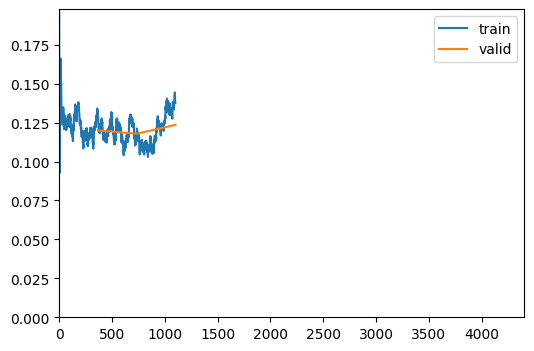

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 1 with valid_loss value: 0.11783605068922043.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


No improvement since epoch 0: early stopping


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
learn.fine_tune(12, base_lr=1e-2)

### ConvNext

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='ConvNext')
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=256,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_clean, bs=64)

In [ ]:
learn = vision_learner(dls, convnext_base, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:02<00:00, 142MB/s]


SuggestedLRs(valley=0.00363078061491251)

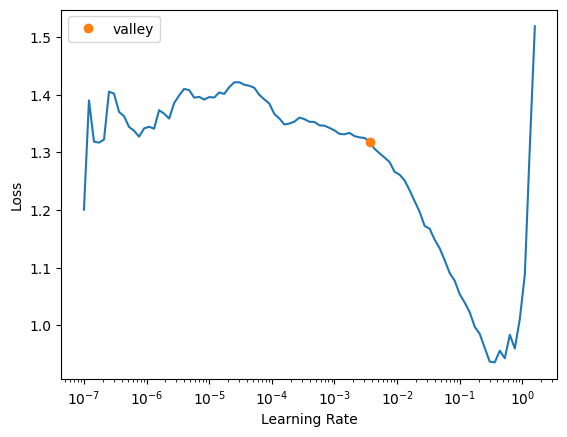

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.282435,0.133290,0.975365,0.000000,0.000000,0.000000,06:34


Better model found at epoch 0 with valid_loss value: 0.1332903951406479.


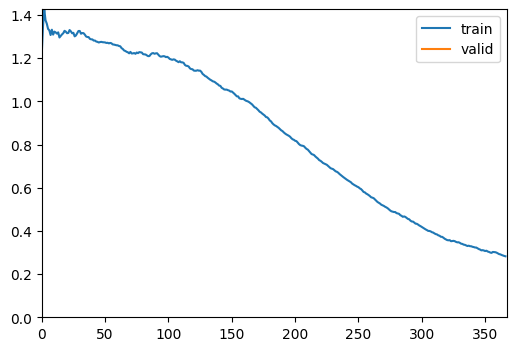

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.154770,0.124533,0.975705,0.000000,0.000000,0.000000,07:22
1,0.135925,0.126319,0.975705,0.000000,0.000000,0.000000,07:20
2,0.117135,0.124998,0.975705,0.000000,0.000000,0.000000,07:23
3,0.104079,0.113192,0.975705,0.000000,0.000000,0.000000,07:19


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.12453320622444153.


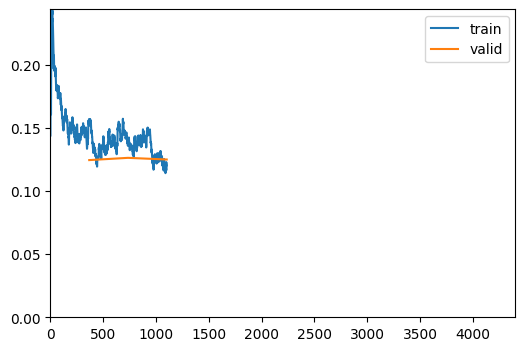

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 3 with valid_loss value: 0.11319191753864288.
No improvement since epoch 0: early stopping


In [ ]:
learn.fine_tune(12, base_lr=1e-3)

### Hrnet

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Hrnet')
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=256,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_clean, bs=32)

In [ ]:
learn = vision_learner(dls, 'hrnet_w44', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

SuggestedLRs(valley=0.009120108559727669)

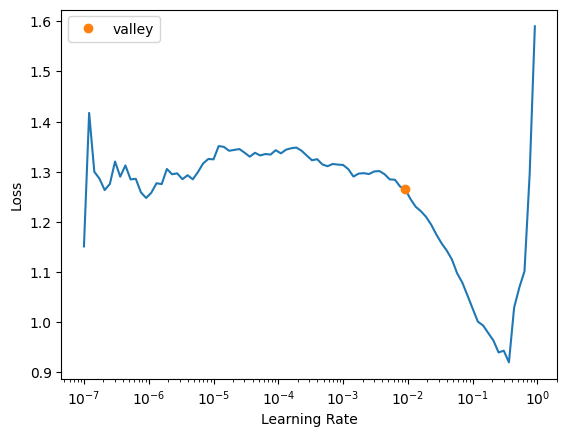

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.152753,0.228862,0.975705,0.000000,0.000000,0.000000,08:37


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.2288622111082077.


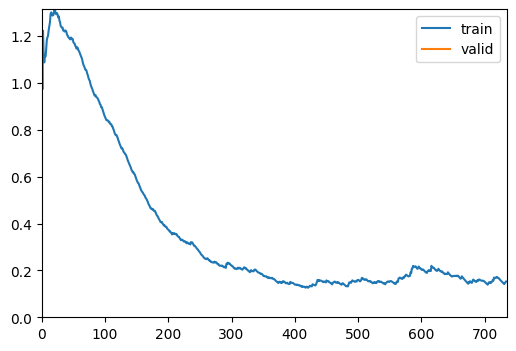

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.108514,0.116335,0.975705,0.000000,0.000000,0.000000,10:49
1,0.130877,0.113926,0.975705,0.000000,0.000000,0.000000,10:49
2,0.117242,0.131944,0.975705,0.000000,0.000000,0.000000,10:56
3,0.129706,0.142787,0.975705,0.000000,0.000000,0.000000,10:47


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.1163351833820343.


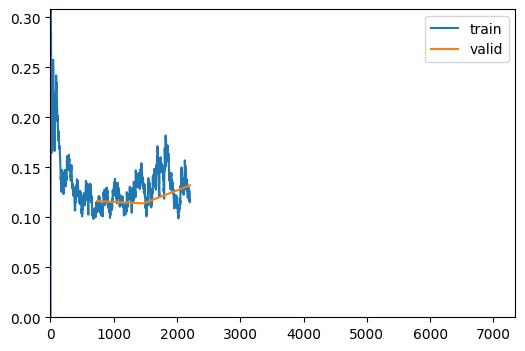

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 1 with valid_loss value: 0.1139262393116951.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


No improvement since epoch 0: early stopping


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

### Deit

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Deit')
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(384), # Solo funciona con este tamaño
                 batch_tfms=aug_transforms(size=384,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_clean, bs=8)

In [ ]:
learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

SuggestedLRs(valley=0.0008317637839354575)

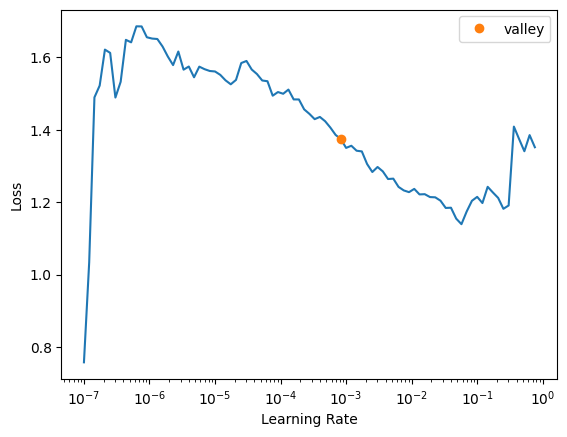

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.163718,0.130346,0.975875,0.000000,0.000000,0.000000,11:37


Better model found at epoch 0 with valid_loss value: 0.1303463578224182.


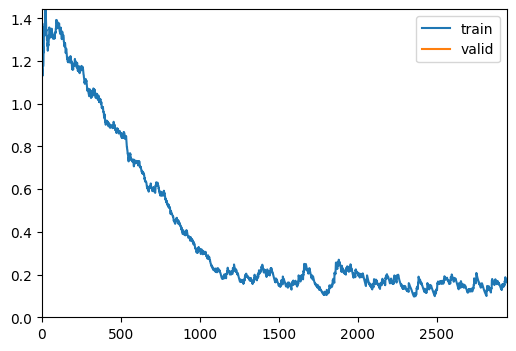

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.123457,0.102459,0.979273,0.000000,0.000000,0.000000,15:24


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.10245919972658157.


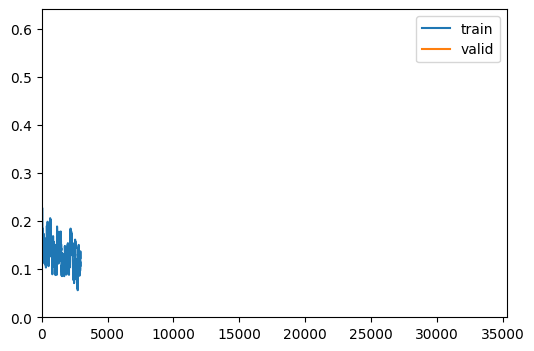

KeyboardInterrupt: ignored

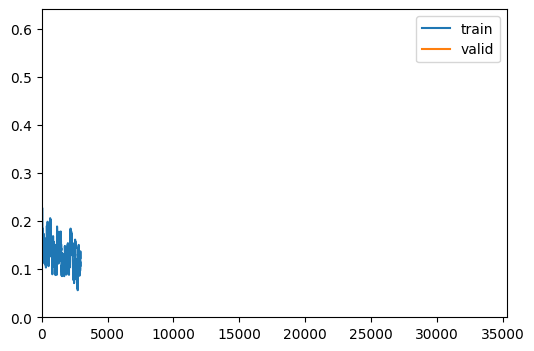

In [ ]:
learn.fine_tune(12, base_lr=1e-3)

## Balanceo

In [9]:
dfna

,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,density,machine_id,difficult_negative_case
12,10038,1967300488,L,MLO,60.0,0,0,0,1.0,C,216,False
13,10038,2142944869,L,CC,60.0,0,0,0,1.0,C,216,False
14,10038,850559196,R,MLO,60.0,0,0,0,1.0,C,216,False
15,10038,1350492010,R,CC,60.0,0,0,0,1.0,C,216,False
16,10042,102733848,L,CC,51.0,0,0,0,1.0,C,93,False
...,...,...,...,...,...,...,...,...,...,...,...,...
54701,9973,1729524723,R,MLO,43.0,0,0,0,1.0,C,49,False
54702,9989,63473691,L,MLO,60.0,0,0,0,NaN,C,216,False
54703,9989,1078943060,L,CC,60.0,0,0,0,NaN,C,216,False
54704,9989,398038886,R,MLO,60.0,0,0,0,0.0,C,216,True


In [10]:
tam = dfna.loc[dfna["cancer"] == 1]["patient_id"].unique().size

In [11]:
X = dfna.loc[::, dfna.columns.drop("cancer")].copy()
y = dfna.loc[::, "cancer"].copy()

In [12]:
y.value_counts()

0    28769
1      664
Name: cancer, dtype: int64

Los datos están claramente desbalanceados. Se va a escoger al azar los elementos de la clase mayoritaria para entrenar a los modelos.

In [13]:
np.random.seed(0)
patients = np.random.choice(dfna.loc[dfna["cancer"] == 0]["patient_id"], tam)
patients = np.concatenate((patients, dfna.loc[dfna["cancer"] == 1]["patient_id"].unique()))
patients.size

504

In [14]:
dfb = dfna.loc[dfna["patient_id"].isin(patients)].copy()

In [15]:
dfb["cancer"].value_counts()

0    1933
1     664
Name: cancer, dtype: int64

In [16]:
import os
import shutil

p_under = path/"undersampled"

if not os.path.isdir(p_under):
    os.mkdir(p_under)

for index, row in dfb.iterrows():
    patient = row["patient_id"]
    shutil.copytree(p_clean/str(patient), p_under/str(patient), dirs_exist_ok=True)

In [17]:
def cadena2(path):
    partes = path.split(os.path.sep)
    return partes[0][:-4]

def label_func2(fname):
    return dfb.loc[dfb['image_id'] == int(cadena2(fname.name))]['cancer'].values[0]

## Modelos undersampling

### Resnet50

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=256,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=32)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='modelResnet50')
]

In [ ]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 139MB/s]


SuggestedLRs(valley=0.019054606556892395)

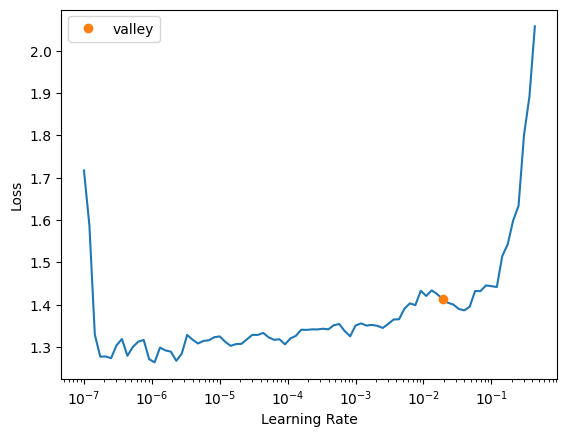

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.121060,0.739784,0.701349,0.309091,0.126866,0.179894,00:40


Better model found at epoch 0 with valid_loss value: 0.739784300327301.


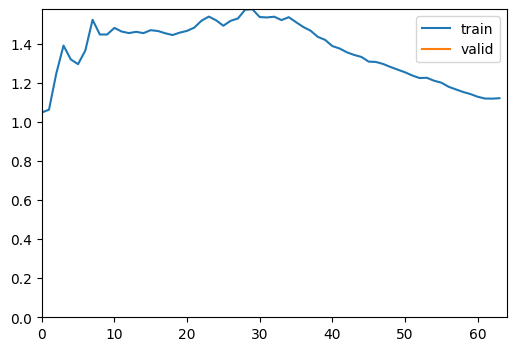

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.692248,0.596437,0.737958,0.250000,0.007463,0.014493,00:32
1,0.635792,0.548251,0.749518,1.000000,0.029851,0.057971,00:31
2,0.637659,0.608542,0.643545,0.321678,0.343284,0.332130,00:31
3,0.619487,0.672485,0.710983,0.357143,0.149254,0.210526,00:50
4,0.677545,1.114706,0.668593,0.268293,0.164179,0.203704,00:45
5,0.660659,0.691687,0.630058,0.327381,0.410448,0.364238,00:31
6,0.663838,0.565843,0.693642,0.365591,0.253731,0.299559,00:33
7,0.646579,0.606087,0.724470,0.235294,0.029851,0.052980,00:35
8,0.641166,0.678980,0.736031,0.333333,0.022388,0.041958,00:32


Better model found at epoch 0 with valid_loss value: 0.596437394618988.


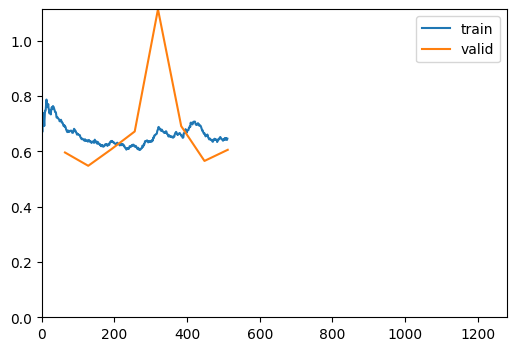

Better model found at epoch 1 with valid_loss value: 0.5482512712478638.
No improvement since epoch 5: early stopping


In [ ]:
learn.fine_tune(20, base_lr=1e-2)

### EfficientNet

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=256,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=16)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='efficientNetB3')
]

In [ ]:
learn = vision_learner(dls, efficientnet_b3, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-cf984f9c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-cf984f9c.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 260MB/s]


SuggestedLRs(valley=0.0002754228771664202)

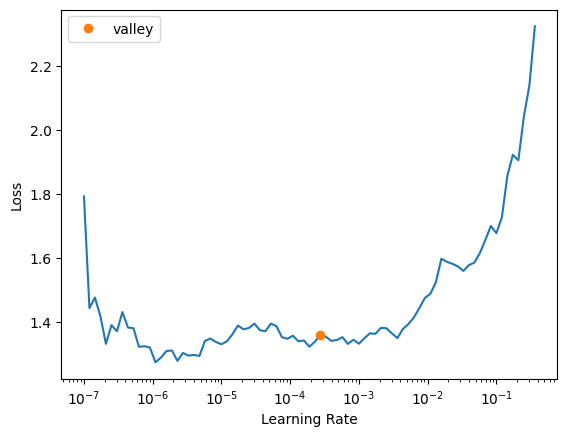

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.266981,1.089923,0.560694,0.244565,0.335821,0.283019,00:55


Better model found at epoch 0 with valid_loss value: 1.0899231433868408.


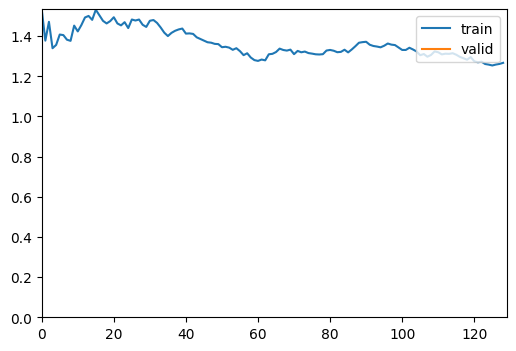

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.066762,0.836467,0.597302,0.295082,0.402985,0.340694,00:47
1,0.996766,0.791438,0.641618,0.286885,0.261194,0.273437,00:45
2,0.873766,0.756540,0.657033,0.284314,0.216418,0.245763,00:44
3,0.871189,0.808300,0.626204,0.227273,0.186567,0.204918,00:46


Better model found at epoch 0 with valid_loss value: 0.8364669680595398.


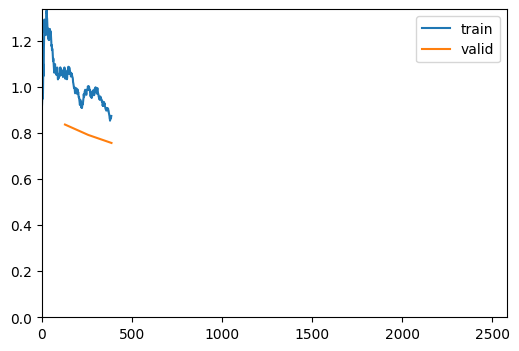

Better model found at epoch 1 with valid_loss value: 0.7914384007453918.
Better model found at epoch 2 with valid_loss value: 0.7565401792526245.
No improvement since epoch 0: early stopping


In [ ]:
learn.fine_tune(20, base_lr=1e-3)

### ConvNext

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=256,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=16)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='ConvNext')
]

In [ ]:
learn = vision_learner(dls, convnext_base, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:06<00:00, 58.8MB/s]


SuggestedLRs(valley=0.00013182566908653826)

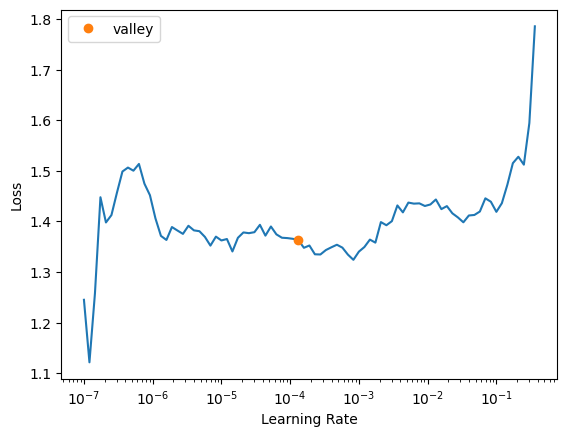

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.270478,0.818702,0.560694,0.302521,0.537313,0.387097,00:45


Better model found at epoch 0 with valid_loss value: 0.8187018036842346.


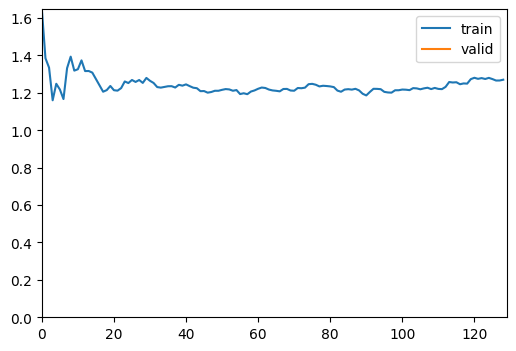

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.182385,0.799886,0.574181,0.301370,0.492537,0.373938,00:48
1,1.195761,0.760988,0.579961,0.294118,0.447761,0.355030,00:50
2,1.137218,0.817069,0.562620,0.300429,0.522388,0.381471,00:49
3,1.092539,0.828791,0.554913,0.298755,0.537313,0.384000,00:49
4,1.095642,0.794256,0.585742,0.304348,0.470149,0.369501,00:50
5,0.967779,0.745547,0.620424,0.327869,0.447761,0.378549,00:49
6,0.962839,0.718148,0.618497,0.316092,0.410448,0.357143,00:50


Better model found at epoch 0 with valid_loss value: 0.7998860478401184.


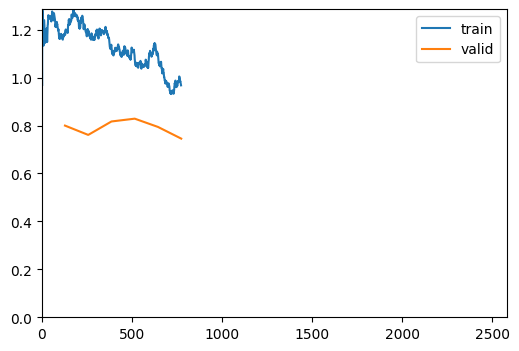

Better model found at epoch 1 with valid_loss value: 0.7609878182411194.
Better model found at epoch 5 with valid_loss value: 0.7455471754074097.
Better model found at epoch 6 with valid_loss value: 0.7181482911109924.
No improvement since epoch 3: early stopping


In [ ]:
learn.fine_tune(20, base_lr=1e-4)

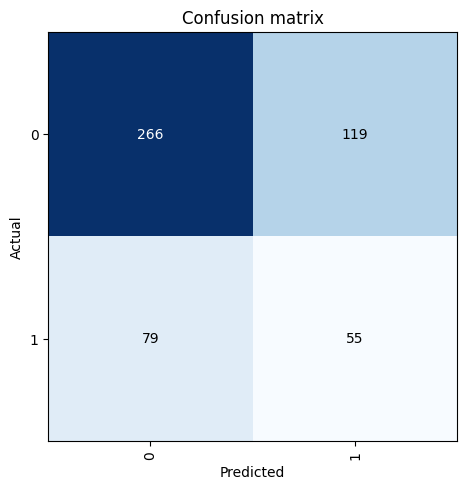

In [ ]:
ClassificationInterpretation.from_learner(learn).plot_confusion_matrix()

### Hrnet

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=256,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=8)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Hrnet')
]

In [ ]:
learn = vision_learner(dls, 'hrnet_w44', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

SuggestedLRs(valley=2.0892961401841603e-05)

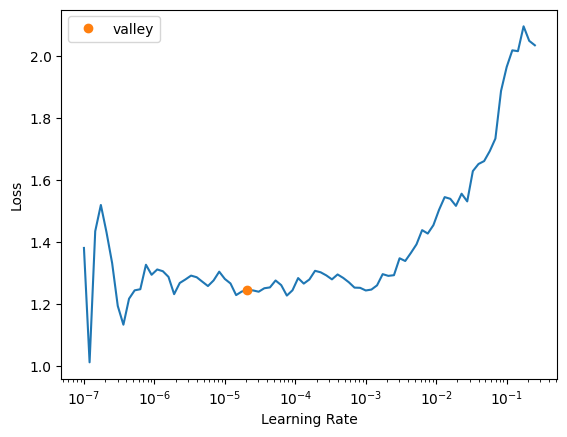

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.232734,0.872708,0.510597,0.258065,0.477612,0.335079,01:50


Better model found at epoch 0 with valid_loss value: 0.8727083206176758.


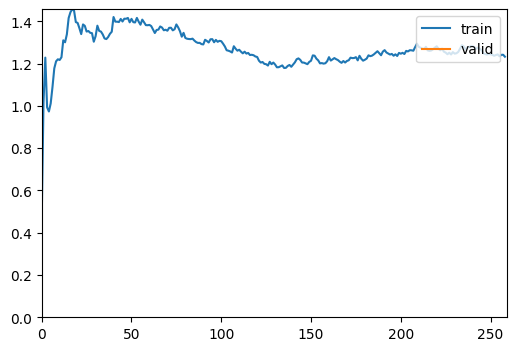

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.318820,0.844452,0.526012,0.238318,0.380597,0.293103,02:07
1,1.353668,0.835255,0.545279,0.266055,0.432836,0.329545,02:10
2,1.313084,0.874952,0.506744,0.227679,0.380597,0.284916,02:10
3,1.234620,0.818241,0.527938,0.251121,0.417910,0.313725,02:10
4,1.114373,0.809375,0.539499,0.266667,0.447761,0.334262,02:09
5,1.223541,0.765961,0.579961,0.278947,0.395522,0.327160,02:09
6,1.215741,0.767407,0.585742,0.265896,0.343284,0.299674,02:10
7,1.088603,0.772592,0.568401,0.247191,0.328358,0.282051,02:07


Better model found at epoch 0 with valid_loss value: 0.8444523215293884.


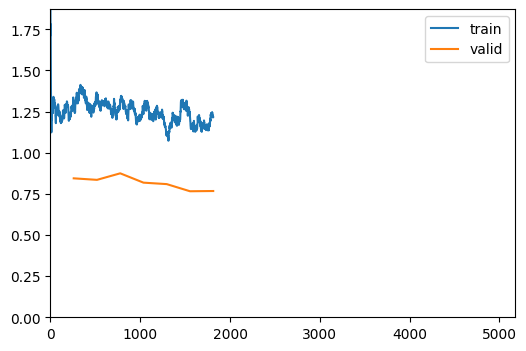

Better model found at epoch 1 with valid_loss value: 0.8352553248405457.
Better model found at epoch 3 with valid_loss value: 0.8182412981987.
Better model found at epoch 4 with valid_loss value: 0.8093748092651367.
Better model found at epoch 5 with valid_loss value: 0.7659607529640198.
No improvement since epoch 4: early stopping


In [ ]:
learn.fine_tune(20, base_lr=1e-5)

### Deit

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(384),
                 batch_tfms=aug_transforms(size=384,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=8)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Deit')
]

In [ ]:
learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

SuggestedLRs(valley=0.0006918309954926372)

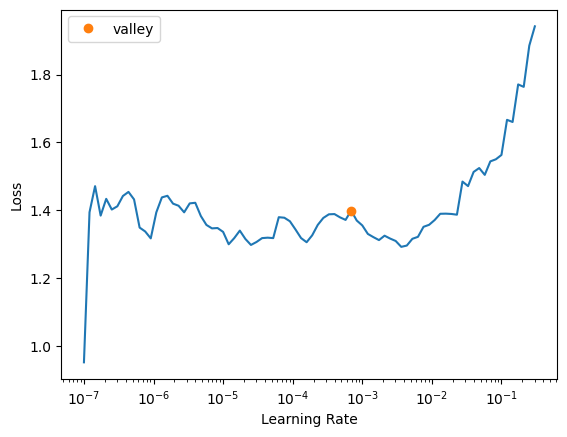

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.049356,0.883991,0.651252,0.288288,0.238806,0.261224,01:01


Better model found at epoch 0 with valid_loss value: 0.8839905858039856.


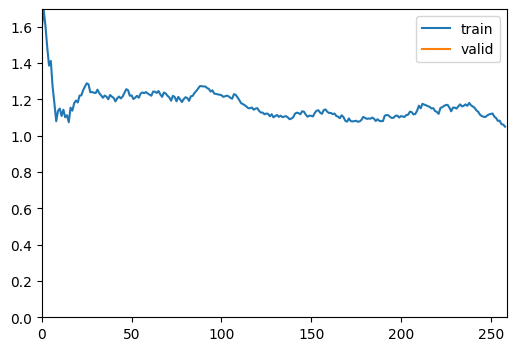

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.829950,0.674525,0.701349,0.315789,0.134328,0.188482,01:21
1,0.846604,0.647892,0.687861,0.354167,0.253731,0.295652,01:23
2,0.788958,0.629204,0.714836,0.405405,0.223881,0.288462,01:24
3,0.725651,0.722911,0.684008,0.232143,0.097015,0.136842,01:22
4,0.648670,0.642820,0.710983,0.166667,0.029851,0.050633,01:23


Better model found at epoch 0 with valid_loss value: 0.6745250821113586.


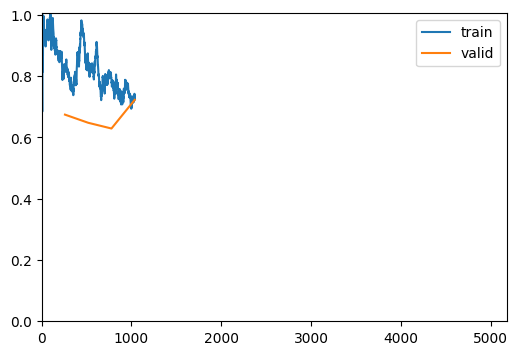

Better model found at epoch 1 with valid_loss value: 0.6478917598724365.
Better model found at epoch 2 with valid_loss value: 0.6292039752006531.
No improvement since epoch 1: early stopping


In [ ]:
learn.fine_tune(20, base_lr=1e-3)

## Balanceo v2

Esta vez se a a probar a balancear por imagenes en vez de por pacientes a ver qué ocurre.

In [18]:
tam = dfna.loc[dfna["cancer"] == 1]["image_id"].size

In [19]:
np.random.seed(0)
images = dfna.loc[dfna["cancer"] == 1]["image_id"]
images = np.concatenate((images, np.random.choice(dfna.loc[dfna["cancer"] == 0]["image_id"], tam)))
images.size

1328

In [20]:
dfb2 = dfna.loc[dfna["image_id"].isin(images)].copy()

In [21]:
dfb2["cancer"].value_counts()

1    664
0    656
Name: cancer, dtype: int64

In [22]:
import os
import shutil

p_under2 = path/"undersampled_v2"

if not os.path.isdir(p_under2):
    os.mkdir(p_under2)

for index, row in dfb2.iterrows():
    patient = row["patient_id"]
    if not os.path.isdir(p_under2/str(patient)):
        os.mkdir(p_under2/str(patient))
    image = row["image_id"]
    src = p_clean/str(patient)/(str(image)+'.jpg')
    dst = p_under2/str(patient)/(str(image)+'.jpg')
    shutil.copyfile(src, dst)

In [23]:
def cadena3(path):
    partes = path.split(os.path.sep)
    return partes[0][:-4]

def label_func3(fname):
    return dfb2.loc[dfb2['image_id'] == int(cadena3(fname.name))]['cancer'].values[0]

## Modelos undersampling v2

### Resnet50

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under2, bs=32)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='modelResnet50')
]

In [ ]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


SuggestedLRs(valley=0.0002290867705596611)

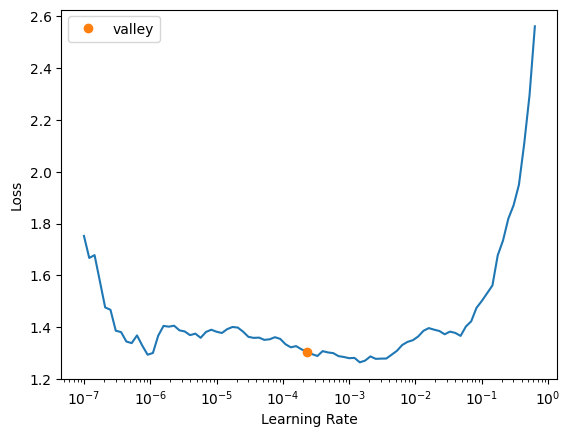

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.166645,0.843130,0.602273,0.589474,0.805755,0.680851,00:23


Better model found at epoch 0 with valid_loss value: 0.8431300520896912.


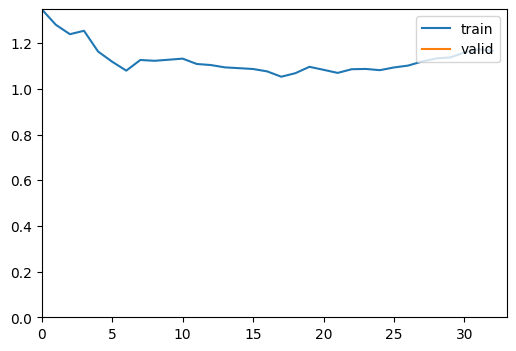

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.046890,0.834805,0.602273,0.594444,0.769784,0.670846,00:25
1,1.098928,0.886394,0.579545,0.576923,0.755396,0.654206,00:25
2,1.083894,0.847347,0.594697,0.593023,0.733813,0.655949,00:26
3,1.057548,0.812880,0.598485,0.612245,0.647482,0.629371,00:26


Better model found at epoch 0 with valid_loss value: 0.8348050117492676.


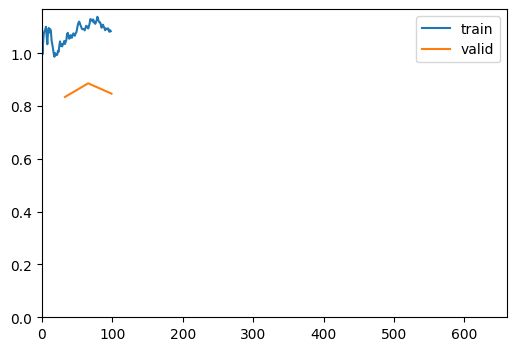

Better model found at epoch 3 with valid_loss value: 0.8128798007965088.
No improvement since epoch 0: early stopping


In [ ]:
learn.fine_tune(20, base_lr=1e-4)

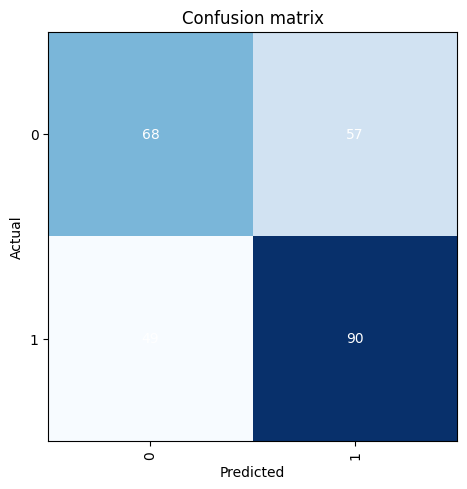

In [ ]:
ClassificationInterpretation.from_learner(learn).plot_confusion_matrix()

### EfficientNet

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under2, bs=16)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='efficientNetB3')
]

In [ ]:
learn = vision_learner(dls, efficientnet_b3, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


SuggestedLRs(valley=4.365158383734524e-05)

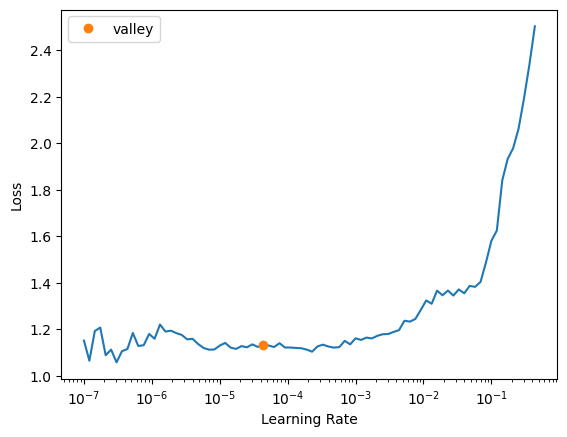

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.302450,nan,0.503788,0.555556,0.287770,0.379147,00:31


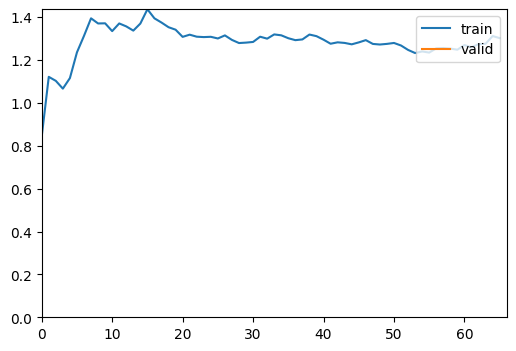

FileNotFoundError: ignored

In [ ]:
learn.fine_tune(20, base_lr=1e-4)

### ConvNext

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under2, bs=16)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='ConvNext')
]

In [ ]:
learn = vision_learner(dls, convnext_base, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:02<00:00, 118MB/s] 


SuggestedLRs(valley=0.0002290867705596611)

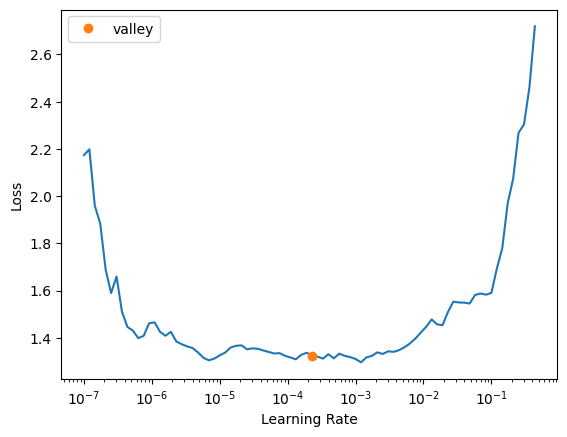

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.926608,1.044007,0.515152,0.627907,0.194245,0.296703,01:01


Better model found at epoch 0 with valid_loss value: 1.0440073013305664.


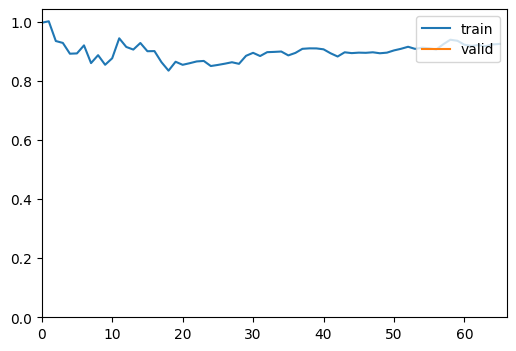

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.855426,1.063406,0.518939,0.650000,0.187050,0.290503,01:14
1,0.823753,0.971291,0.560606,0.701754,0.287770,0.408163,01:15
2,0.865390,0.914428,0.598485,0.732394,0.374101,0.495238,01:14
3,0.866003,0.992888,0.549242,0.678571,0.273381,0.389744,01:14
4,0.912033,0.970253,0.564394,0.700000,0.302158,0.422111,01:14
5,0.851455,1.032772,0.515152,0.617021,0.208633,0.311828,01:13


Better model found at epoch 0 with valid_loss value: 1.0634058713912964.


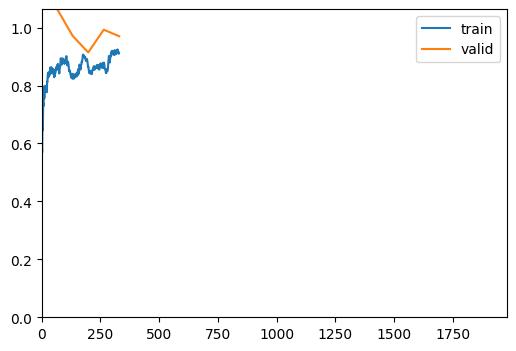

Better model found at epoch 1 with valid_loss value: 0.9712909460067749.
Better model found at epoch 2 with valid_loss value: 0.9144281148910522.
No improvement since epoch 2: early stopping


In [ ]:
learn.fine_tune(20, base_lr=1e-4)

Ha tardado 25 minutos.

### Hrnet

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under2, bs=8)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Hrnet')
]

In [ ]:
learn = vision_learner(dls, 'hrnet_w44', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

SuggestedLRs(valley=0.00019054606673307717)

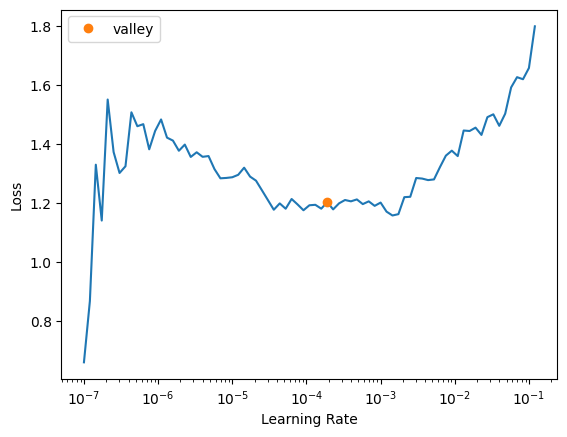

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.287252,0.850548,0.537879,0.555556,0.611511,0.582192,01:27


Better model found at epoch 0 with valid_loss value: 0.8505479097366333.


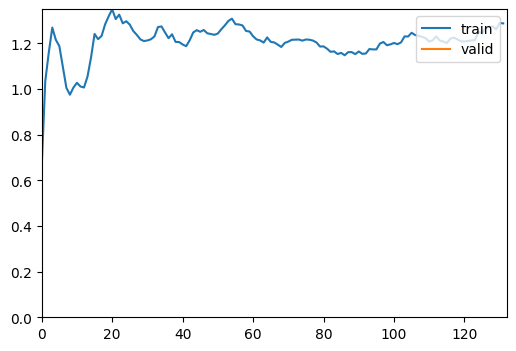

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.332537,0.837063,0.526515,0.552239,0.532374,0.542125,01:52
1,1.148416,0.830813,0.560606,0.573248,0.647482,0.608108,01:52
2,1.202800,0.840651,0.541667,0.563380,0.575540,0.569395,01:52
3,1.090528,0.852386,0.503788,0.530769,0.496403,0.513011,01:52
4,1.096312,0.873479,0.545455,0.577236,0.510791,0.541985,01:52


Better model found at epoch 0 with valid_loss value: 0.8370627164840698.


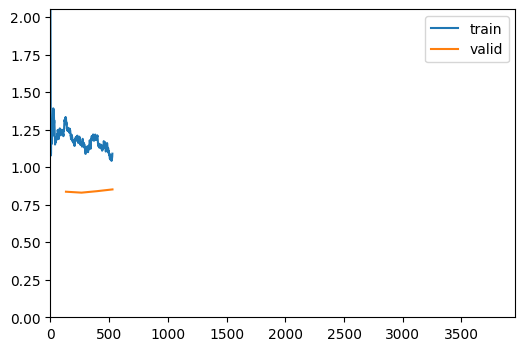

Better model found at epoch 1 with valid_loss value: 0.8308134078979492.
No improvement since epoch 1: early stopping


In [ ]:
learn.fine_tune(20, base_lr=1e-4)

### Deit

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=384,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under2, bs=8)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Deit')
]

In [ ]:
learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

SuggestedLRs(valley=0.0012022644514217973)

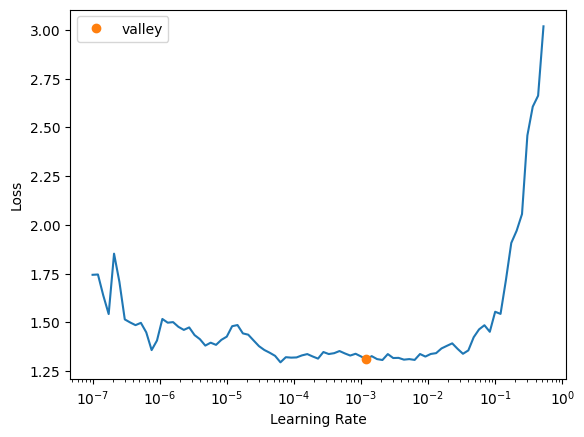

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.277721,1.004139,0.564394,0.620000,0.446043,0.518828,00:40


Better model found at epoch 0 with valid_loss value: 1.0041393041610718.


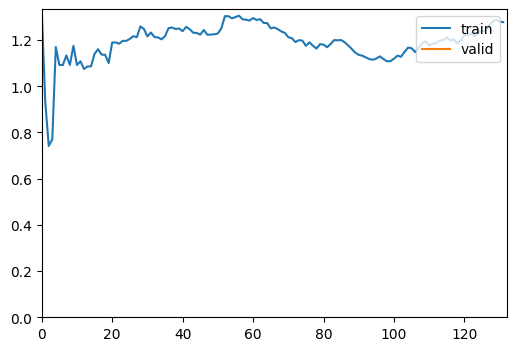

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.031405,0.856790,0.564394,0.615385,0.460432,0.526749,00:42
1,0.966767,0.768990,0.643939,0.661871,0.661871,0.661871,00:43
2,0.919604,0.713353,0.647727,0.685484,0.611511,0.646388,00:42
3,0.906435,0.832461,0.579545,0.588608,0.669065,0.626263,00:44
4,0.835320,0.840183,0.643939,0.722772,0.525180,0.608333,00:44


Better model found at epoch 0 with valid_loss value: 0.8567897081375122.


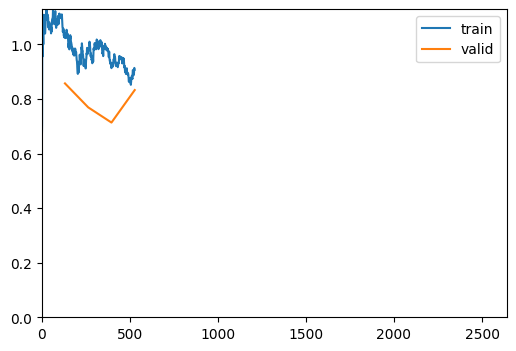

Better model found at epoch 1 with valid_loss value: 0.7689902186393738.
Better model found at epoch 2 with valid_loss value: 0.7133527398109436.
No improvement since epoch 1: early stopping


In [ ]:
learn.fine_tune(20, base_lr=1e-3)

## Multi-Task

In [24]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
dfb2["density"] = enc.fit_transform(np.array(dfb2["density"]).reshape(-1,1))
dfb2["density"]

87       1.0
88       1.0
89       1.0
90       1.0
145      2.0
        ... 
54477    0.0
54481    0.0
54523    2.0
54545    2.0
54643    2.0
Name: density, Length: 1320, dtype: float64

In [25]:
dfb2["density"] = dfb2["density"].astype(int)
dfb2["age"] = dfb2["age"].astype(int)
dfb2

,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,density,machine_id,difficult_negative_case
87,10130,388811999,L,MLO,71,1,1,1,0.0,1,49,False
88,10130,613462606,L,CC,71,1,1,1,0.0,1,49,False
89,10130,1360338805,L,CC,71,1,1,1,0.0,1,49,False
90,10130,1672636630,L,MLO,71,1,1,1,0.0,1,49,False
145,10185,1385708909,R,CC,50,0,0,0,1.0,2,49,False
...,...,...,...,...,...,...,...,...,...,...,...,...
54477,9705,1760777835,L,MLO,64,0,0,0,1.0,0,49,False
54481,9705,1128107021,R,MLO,64,0,0,0,1.0,0,49,False
54523,9750,2028693570,L,CC,42,0,0,0,0.0,2,49,True
54545,9783,820355191,R,CC,56,0,1,0,0.0,2,216,True


In [26]:
label = []
for i, row in dfb2.iterrows():
    edad = str(int(row["age"]))
    cancer = str(row["cancer"])
    densidad = str(row["density"])
    if '.' in densidad:
        densidad = densidad[0]
    label.append(edad + ' ' + cancer + ' ' + densidad)
dfb2["label"] = label
dfb2

,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,density,machine_id,difficult_negative_case,label
87,10130,388811999,L,MLO,71,1,1,1,0.0,1,49,False,71 1 1
88,10130,613462606,L,CC,71,1,1,1,0.0,1,49,False,71 1 1
89,10130,1360338805,L,CC,71,1,1,1,0.0,1,49,False,71 1 1
90,10130,1672636630,L,MLO,71,1,1,1,0.0,1,49,False,71 1 1
145,10185,1385708909,R,CC,50,0,0,0,1.0,2,49,False,50 0 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54477,9705,1760777835,L,MLO,64,0,0,0,1.0,0,49,False,64 0 0
54481,9705,1128107021,R,MLO,64,0,0,0,1.0,0,49,False,64 0 0
54523,9750,2028693570,L,CC,42,0,0,0,0.0,2,49,True,42 0 2
54545,9783,820355191,R,CC,56,0,1,0,0.0,2,216,True,56 0 2


In [27]:
class MultiTaskDataset():
    def __init__(self, df, tfms, size=64):
        self.paths = []
        for index, row in df.iterrows():
            patient = row["patient_id"]
            image = row["image_id"]
            path = p_under2/str(patient)/(str(image) + '.jpg')
            self.paths.append(path)
        self.labels = list(df["label"])
        self.tfms = tfms
        self.size = size
        self.train = df.copy()
        self.norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) #imagenet stats

    def __len__(self): return len(self.paths)

    def __getitem__(self,idx):
        #dealing with the image
        img = PIL.Image.open(self.paths[idx]).convert('RGB')
        img = img.resize((256, 256))
        t = torch.Tensor(np.array(img))
        t = t.permute(2, 0, 1).float() / 255.0
        transform = transforms.ToPILImage()
        img = PILImage(PILImage.create(transform(t)))
        img = self.tfms.encodes(img)
        transform = transforms.Compose([transforms.ToTensor()])
        img = self.norm(transform(img))
        #dealing with the labels
        labels = self.labels[idx].split(" ")
        age = torch.tensor(float(labels[0]), dtype=torch.float32)
        cancer = torch.tensor(int(labels[1]), dtype=torch.int64)
        density = torch.tensor(int(labels[2]), dtype=torch.int64)

        return img, (age.log_() / 4.489, cancer, density)

    def show(self,idx):
        x, y = self.__getitem__(idx)
        age, cancer, density = y
        stds = np.array([0.229, 0.224, 0.225])
        means = np.array([0.485, 0.456, 0.406])
        img = ((x.numpy().transpose((1, 2, 0)) * stds + means) * 255).astype(np.uint8)
        plt.imshow(img)
        plt.title("{} {} {}".format(int(age.mul_(4.489).exp_().item()), cancer.item(), density.item()))

In [28]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(dfb2, test_size=0.2)

tfms = aug_transforms()
tdset = MultiTaskDataset(train, tfms[0], size=64)
vdset = MultiTaskDataset(test, tfms[1], size=64)
data = DataLoaders.from_dsets(tdset, vdset, batch_size=4, shuffle=True, device=torch.device('cuda'))

In [29]:
class MultiTaskModel(nn.Module):
    """
    Creates a MTL model with the encoder from "arch" and with dropout multiplier ps.
    """
    def __init__(self, arch, ps=0.5):
        super(MultiTaskModel, self).__init__()
        self.encoder = create_body(arch)        #fastai function that creates an encoder given an architecture
        self.fc1 = create_head(1024, 1, ps=ps)    #fastai function that creates a head
        self.fc2 = create_head(1024, 2, ps=ps)
        self.fc3 = create_head(1024, 4, ps=ps) # 11?

    def forward(self, x):
        x = self.encoder(x)
        age = torch.sigmoid(self.fc1(x))
        cancer = self.fc2(x)
        density = self.fc3(x)

        return [age, cancer, density]

In [74]:
class MultiTaskLossWrapper(nn.Module):
    def __init__(self, task_num):
        super(MultiTaskLossWrapper, self).__init__()
        self.task_num = task_num
        self.log_vars = nn.Parameter(torch.zeros((task_num)))

    def forward(self, preds, label):

        mse, crossEntropy = MSELossFlat(), CrossEntropyLossFlat()

        loss0 = mse(preds[0], label[0])
        loss1 = crossEntropy(preds[1], label[1])
        loss2 = crossEntropy(preds[2], label[2])

        precision0 = torch.exp(-self.log_vars[0])
        loss0 = precision0 * loss0 + self.log_vars[0]

        precision1 = torch.exp(-self.log_vars[1])
        loss1 = precision1 * loss1 + self.log_vars[1]

        precision2 = torch.exp(-self.log_vars[2])
        loss2 = precision2 * loss2 + self.log_vars[2]

        return 3* (0.1 * loss0 + 0.6 * loss1 + 0.3 * loss2)

In [75]:
from sklearn.metrics import f1_score
def rmse_age(preds, labels): return rmse(preds[0], labels[0])
def f1_cancer(preds, labels):
    pred = preds[1].cpu()
    pred = np.array(pred)
    plist = []
    for i in range(len(pred)):
        if pred[i][0] > pred[i][1]:
            plist.append(1)
        else:
            plist.append(0)
    return f1_score(np.array(plist), labels[1].cpu(), zero_division=0)
def acc_density(preds, labels): return accuracy(preds[2], labels[2])

metrics = [rmse_age, f1_cancer, acc_density]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_func = MultiTaskLossWrapper(3).to(device) #just making sure the loss is on the gpu

## Modelos Multi-Task

### ResNet

In [76]:
class MultiTaskModel(nn.Module):
    """
    Creates a MTL model with the encoder from "arch" and with dropout multiplier ps.
    """
    def __init__(self, arch, ps=0.5):
        super(MultiTaskModel, self).__init__()
        self.encoder = create_body(arch)        #fastai function that creates an encoder given an architecture
        self.fc1 = create_head(2048,1,ps=ps)    #fastai function that creates a head
        self.fc2 = create_head(2048,2,ps=ps)
        self.fc3 = create_head(2048,4,ps=ps)

    def forward(self, x):

        x = self.encoder(x)
        age = torch.sigmoid(self.fc1(x))
        cancer = self.fc2(x)
        density = self.fc3(x)

        return [age, cancer, density]

SuggestedLRs(valley=0.0010000000474974513)

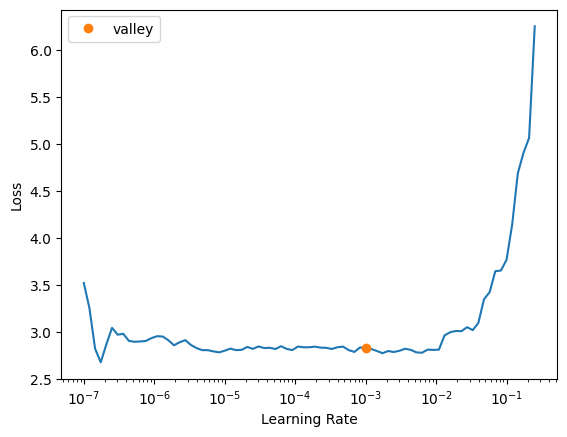

In [77]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_cancer', comp=np.greater, patience=4),
    SaveModelCallback(fname='Resnet50')
]

model = MultiTaskModel(resnet50(), ps=0.25)
learn = Learner(data, model, loss_func=loss_func, cbs=callbacks, metrics=metrics)
learn.lr_find()

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time
0,2.548110,2.510934,0.142274,0.381169,0.337121,00:37


Better model found at epoch 0 with valid_loss value: 2.5109336376190186.


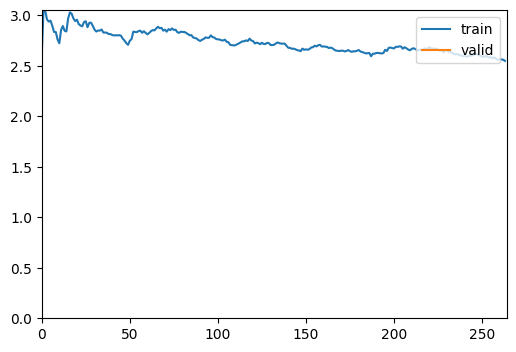

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time
0,2.310601,2.158149,0.065138,0.255556,0.628788,00:31
1,2.251623,2.287471,0.042461,0.403030,0.594697,00:31
2,2.227568,2.463410,0.044019,0.319408,0.545455,00:29
3,2.318775,2.274157,0.045277,0.367172,0.545455,00:30
4,2.298316,2.526394,0.063522,0.420058,0.454545,00:29
5,2.261235,2.146888,0.043249,0.273593,0.609848,00:31
6,2.263862,2.368405,0.041847,0.624964,0.549242,00:30
7,2.411757,7.866852,0.081840,0.102525,0.136364,00:29
8,2.354960,2.928661,0.045222,0.314141,0.405303,00:29
9,2.270198,2.319272,0.042686,0.325758,0.428030,00:30


Better model found at epoch 0 with valid_loss value: 2.1581485271453857.


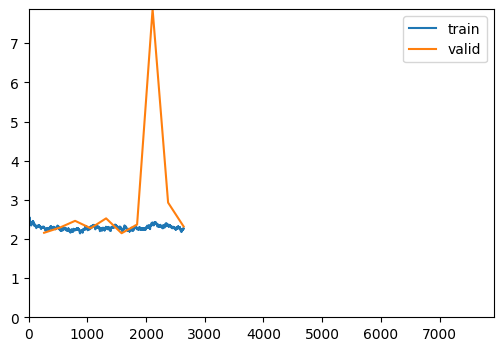

Better model found at epoch 5 with valid_loss value: 2.146888494491577.
Better model found at epoch 10 with valid_loss value: 2.0412561893463135.
No improvement since epoch 6: early stopping


In [78]:
learn.fine_tune(30, base_lr=1e-3)

### EfficientNet

In [79]:
class MultiTaskModel(nn.Module):
    """
    Creates a MTL model with the encoder from "arch" and with dropout multiplier ps.
    """
    def __init__(self, arch, ps=0.5):
        super(MultiTaskModel, self).__init__()
        self.encoder = create_body(arch)        #fastai function that creates an encoder given an architecture
        self.fc1 = create_head(1536,1,ps=ps)    #fastai function that creates a head
        self.fc2 = create_head(1536,2,ps=ps)
        self.fc3 = create_head(1536,4,ps=ps)

    def forward(self, x):

        x = self.encoder(x)
        age = torch.sigmoid(self.fc1(x))
        cancer = self.fc2(x)
        density = self.fc3(x)

        return [age, cancer, density]

SuggestedLRs(valley=2.0892961401841603e-05)

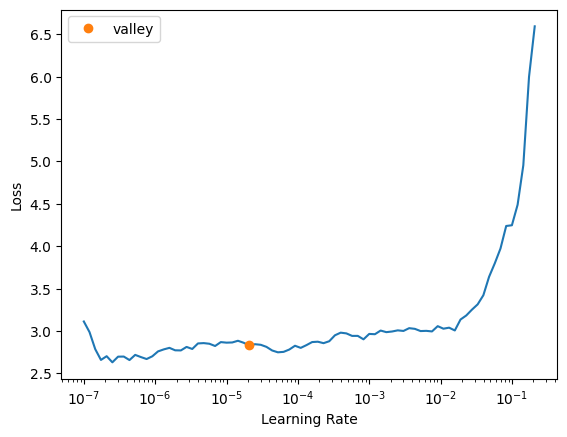

In [80]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_cancer', comp=np.greater, patience=4),
    SaveModelCallback(fname='Efficientnet')
]

model = MultiTaskModel(efficientnet_b3(), ps=0.25)
learn = Learner(data, model, loss_func=loss_func, cbs=callbacks, metrics=metrics)
learn.lr_find()

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time
0,2.863318,2.553964,0.463945,0.151515,0.181818,00:52


Better model found at epoch 0 with valid_loss value: 2.5539636611938477.


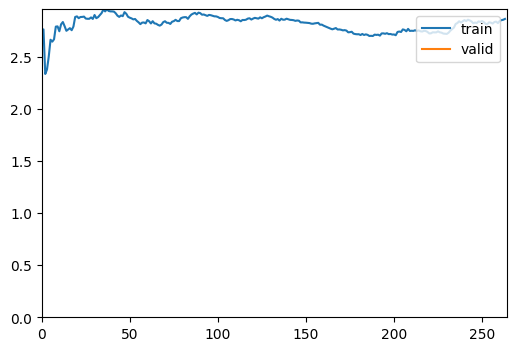

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time
0,2.767993,2.589211,0.407796,0.422799,0.162879,00:43
1,2.689466,2.555294,0.405332,0.409307,0.159091,00:45
2,2.660568,2.592458,0.432840,0.385354,0.140152,00:43
3,2.754923,2.636328,0.416612,0.030303,0.117424,00:43
4,2.715048,2.593838,0.436142,0.358442,0.162879,00:44


Better model found at epoch 0 with valid_loss value: 2.5892114639282227.


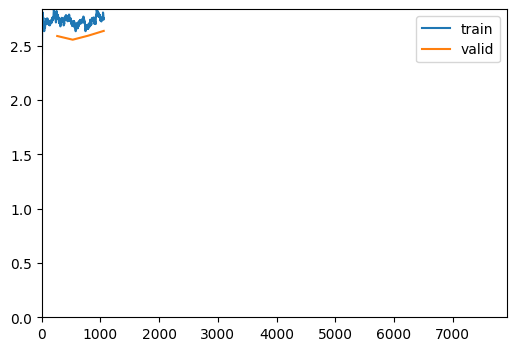

Better model found at epoch 1 with valid_loss value: 2.5552940368652344.
No improvement since epoch 0: early stopping


In [81]:
learn.fine_tune(30, base_lr=1e-5)

### ConvNext

In [82]:
class MultiTaskModel(nn.Module):
    """
    Creates a MTL model with the encoder from "arch" and with dropout multiplier ps.
    """
    def __init__(self, arch, ps=0.5):
        super(MultiTaskModel, self).__init__()
        self.encoder = create_body(arch)        #fastai function that creates an encoder given an architecture
        self.fc1 = create_head(1024,1,ps=ps)    #fastai function that creates a head
        self.fc2 = create_head(1024,2,ps=ps)
        self.fc3 = create_head(1024,4,ps=ps)

    def forward(self, x):

        x = self.encoder(x)
        age = torch.sigmoid(self.fc1(x))
        cancer = self.fc2(x)
        density = self.fc3(x)

        return [age, cancer, density]

SuggestedLRs(valley=0.0012022644514217973)

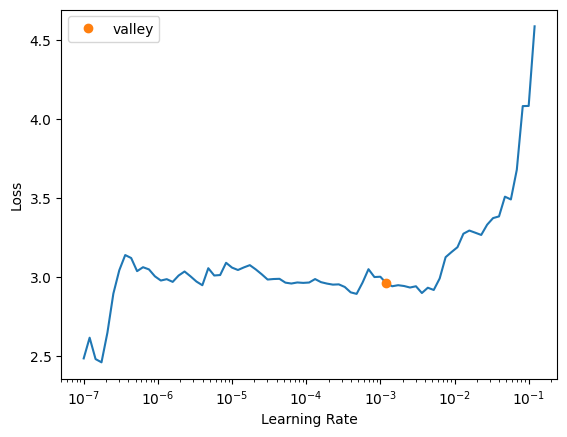

In [83]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_cancer', comp=np.greater, patience=4),
    SaveModelCallback(fname='ConvNext')
]

model = MultiTaskModel(convnext_base(), ps=0.25)
learn = Learner(data, model, loss_func=loss_func, cbs=callbacks, metrics=metrics)
learn.lr_find()

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time
0,2.885181,2.422277,0.118833,0.306566,0.450758,01:25


Better model found at epoch 0 with valid_loss value: 2.4222769737243652.


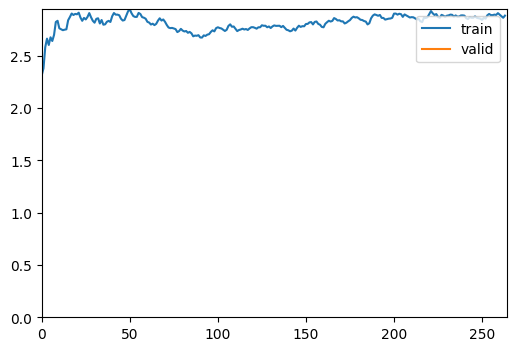

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time
0,2.302217,2.173184,0.070666,0.395960,0.579545,01:25
1,2.175877,2.142832,0.041768,0.273232,0.583333,01:26
2,2.185190,2.106461,0.043847,0.310173,0.564394,01:25
3,2.231041,2.223015,0.050283,0.480592,0.537879,01:25
4,2.270575,3.249622,0.083412,0.629726,0.496212,01:26
5,2.178962,2.377415,0.068023,0.528211,0.640152,01:25
6,2.267272,5.073268,0.569561,0.000000,0.420455,01:25
7,2.206526,2.587237,0.047363,0.630447,0.549242,01:25
8,2.194080,2.655209,0.055330,0.416595,0.500000,01:26
9,2.079023,2.087765,0.048313,0.461688,0.613636,01:25


Better model found at epoch 0 with valid_loss value: 2.1731839179992676.


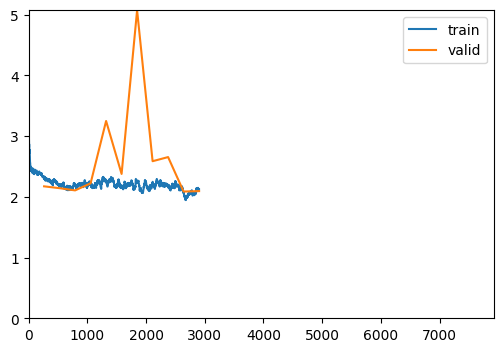

Better model found at epoch 1 with valid_loss value: 2.142831563949585.
Better model found at epoch 2 with valid_loss value: 2.1064605712890625.
Better model found at epoch 9 with valid_loss value: 2.0877654552459717.
No improvement since epoch 7: early stopping


In [84]:
learn.fine_tune(30, base_lr=1e-3)

### HRNet

In [63]:
class MultiTaskModel(nn.Sequential):
    """
    Creates a MTL model with the encoder from "arch" and with dropout multiplier ps.
    """
    def __init__(self, arch, ps=0.5):
        super(MultiTaskModel, self).__init__()
        self.encoder = create_body(arch)        #fastai function that creates an encoder given an architecture
        self.fc1 = create_head(1024,1,ps=ps)    #fastai function that creates a head
        self.fc2 = create_head(1024,2,ps=ps)
        self.fc3 = create_head(1024,4,ps=ps)

    def forward(self, x):

        x = self.encoder(x)
        age = torch.sigmoid(self.fc1(x))
        cancer = self.fc2(x)
        density = self.fc3(x)

        return [age, cancer, density]

In [64]:
from timm import create_model
from fastai.vision.learner import _update_first_layer

def create_timm_body(arch:str, pretrained=True, cut=None, n_in=3):
    "Creates a body from any model in the `timm` library."
    model = create_model(arch, pretrained=pretrained, num_classes=0, global_pool='')
    _update_first_layer(model, n_in, pretrained)
    if cut is None:
        ll = list(enumerate(model.children()))
        cut = next(i for i,o in reversed(ll) if has_pool_type(o))
    if isinstance(cut, int): return nn.Sequential(*list(model.children())[:cut])
    elif callable(cut): return cut(model)
    else: print("cut must be either integer or function")

In [73]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_cancer', comp=np.greater, patience=4),
    SaveModelCallback(fname='Hrnet')
]

body = create_timm_body('hrnet_w44', pretrained=True)
head = create_head(512, 3, concat_pool=True)
net = nn.Sequential(body, head)

model = MultiTaskModel(net, ps=0.25)
learn = Learner(data, model, loss_func=loss_func, cbs=callbacks, metrics=metrics)
learn.fine_tune(30, base_lr=1e-3)

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time


NotImplementedError: ignored

### Deit

In [ ]:
class MultiTaskModel(nn.Module):
    """
    Creates a MTL model with the encoder from "arch" and with dropout multiplier ps.
    """
    def __init__(self, arch, ps=0.5):
        super(MultiTaskModel, self).__init__()
        self.encoder = create_body(arch)        #fastai function that creates an encoder given an architecture
        self.fc1 = create_head(1024,1,ps=ps)    #fastai function that creates a head
        self.fc2 = create_head(1024,2,ps=ps)
        self.fc3 = create_head(1024,4,ps=ps)

    def forward(self, x):

        x = self.encoder(x)
        age = torch.sigmoid(self.fc1(x))
        cancer = self.fc2(x)
        density = self.fc3(x)

        return [age, cancer, density]

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_cancer', comp=np.greater, patience=4),
    SaveModelCallback(fname='Deit')
]

body = create_timm_body('deit3_base_patch16_384', pretrained=True)
nf = num_features_model(body)
head = create_head(nf, data.c, concat_pool=True)
net = nn.Sequential(body, head)

model = MultiTaskModel(net, ps=0.25)
learn = Learner(data, model, loss_func=loss_func, cbs=callbacks, metrics=metrics)
learn.fine_tune(30, base_lr=1e-3)

## Procesamiento de datos

In [ ]:
dfb2

,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,density,machine_id,difficult_negative_case
87,10130,388811999,L,MLO,71.0,1,1,1,0.0,B,49,False
88,10130,613462606,L,CC,71.0,1,1,1,0.0,B,49,False
89,10130,1360338805,L,CC,71.0,1,1,1,0.0,B,49,False
90,10130,1672636630,L,MLO,71.0,1,1,1,0.0,B,49,False
145,10185,1385708909,R,CC,50.0,0,0,0,1.0,C,49,False
...,...,...,...,...,...,...,...,...,...,...,...,...
54477,9705,1760777835,L,MLO,64.0,0,0,0,1.0,A,49,False
54481,9705,1128107021,R,MLO,64.0,0,0,0,1.0,A,49,False
54523,9750,2028693570,L,CC,42.0,0,0,0,0.0,C,49,True
54545,9783,820355191,R,CC,56.0,0,1,0,0.0,C,216,True


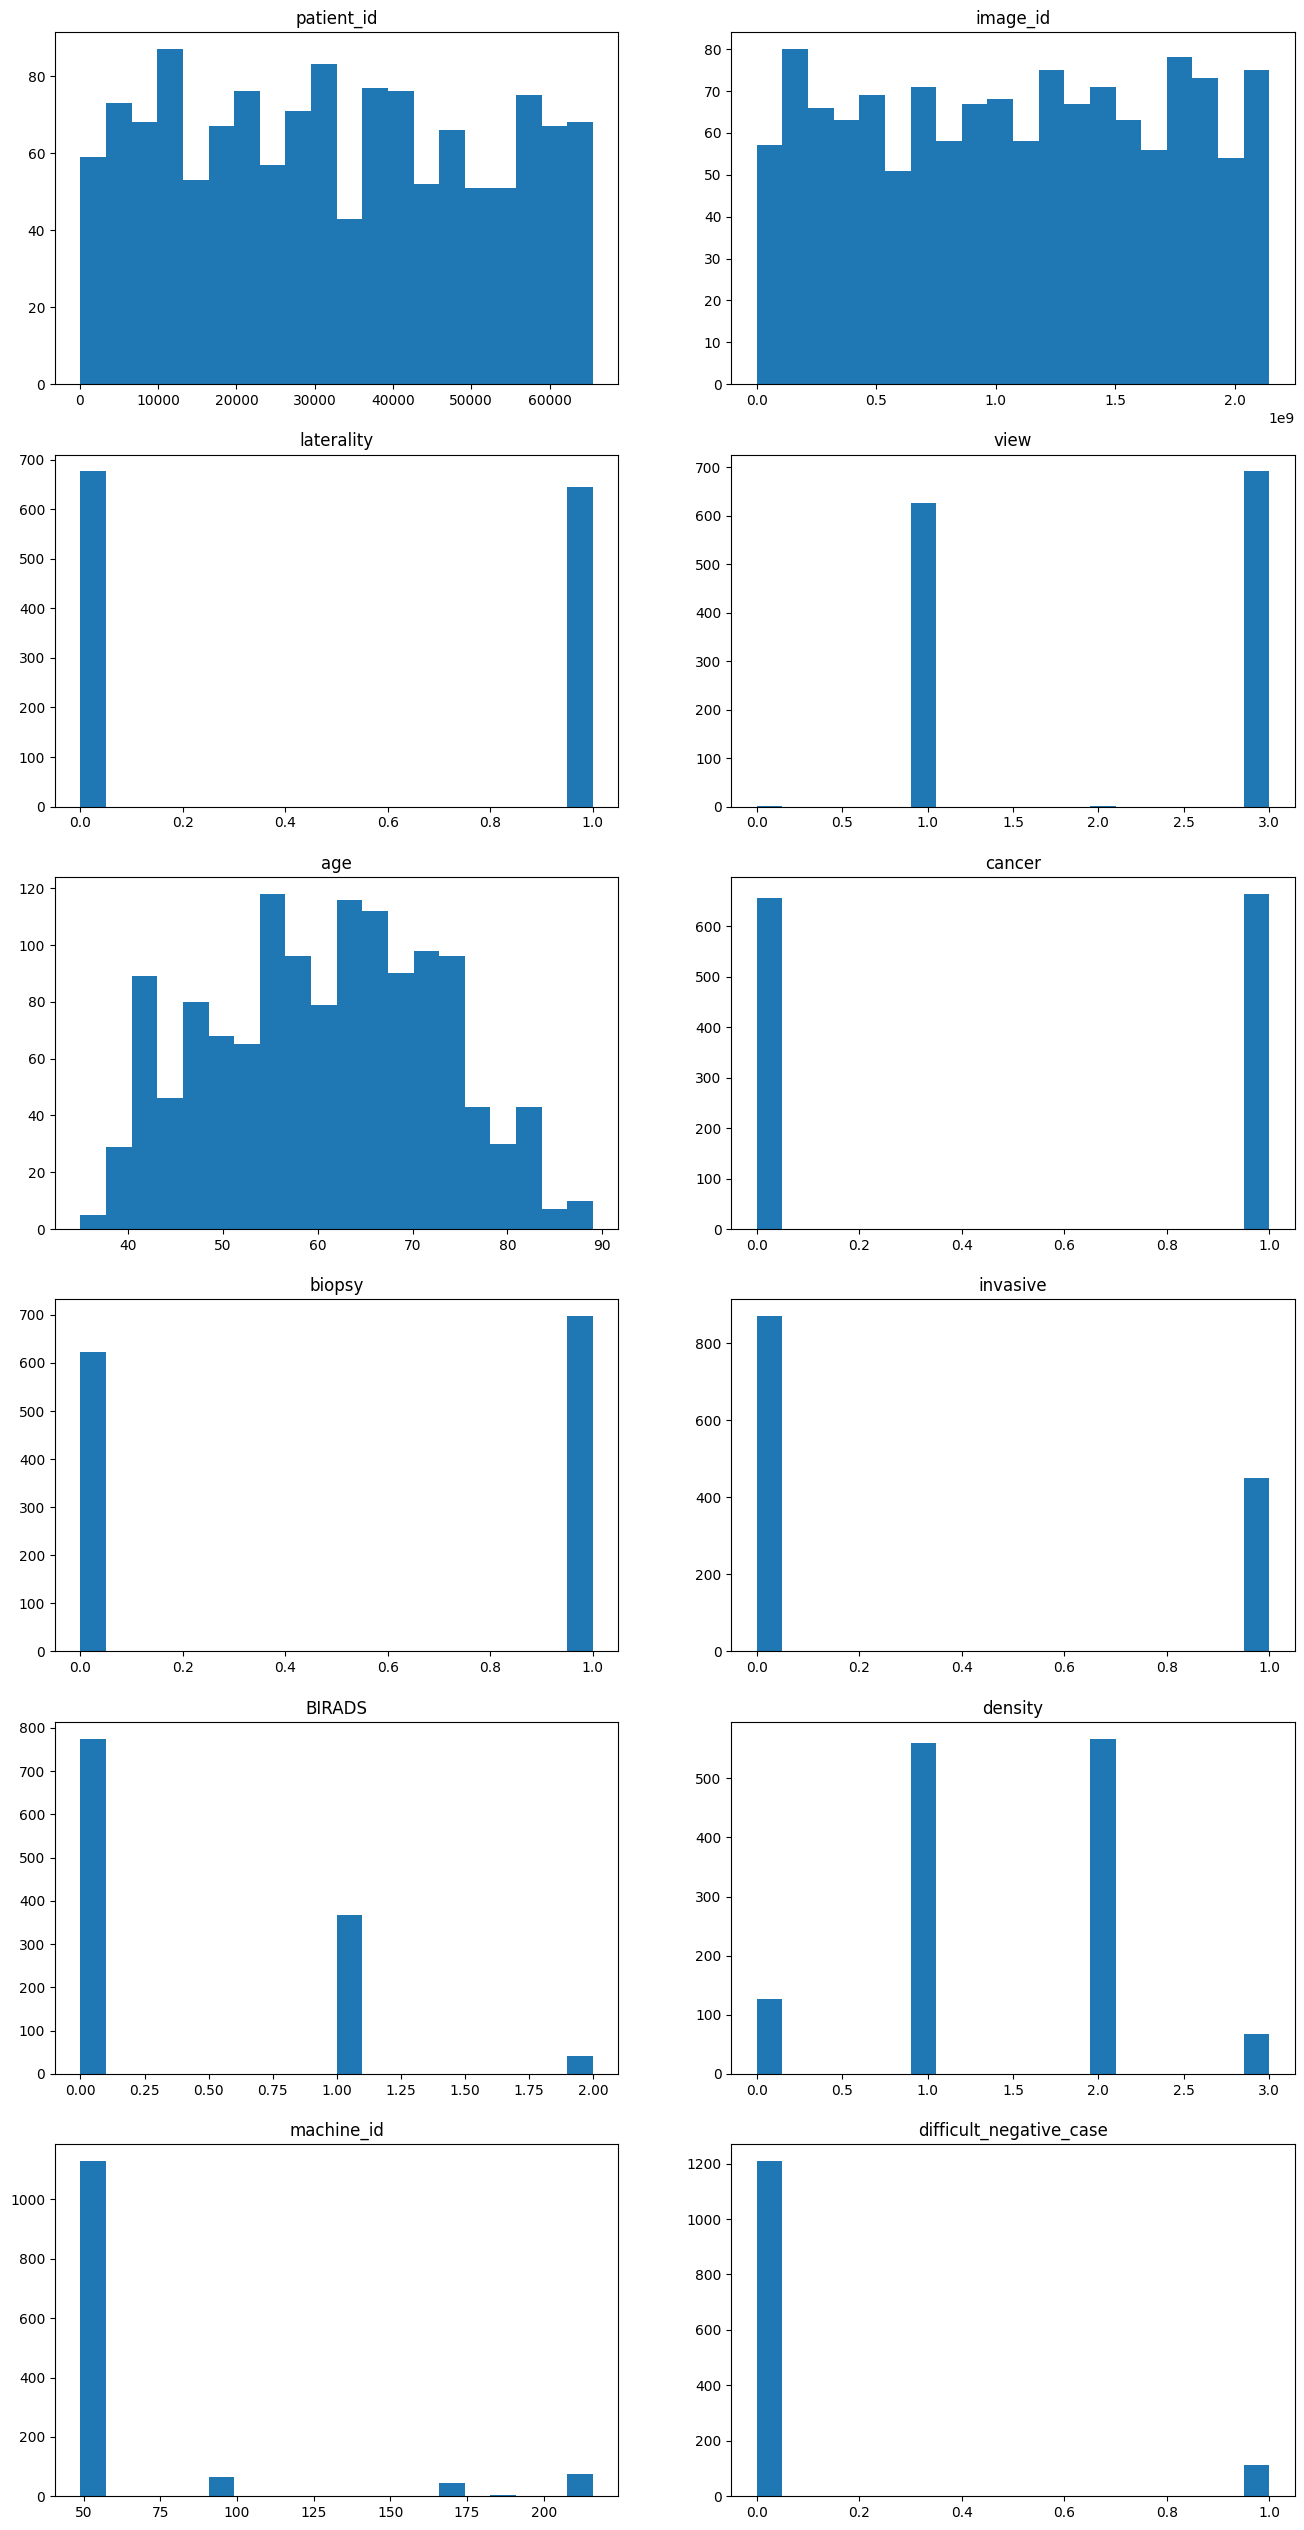

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
dfb2[["laterality","view","density","difficult_negative_case"]] = enc.fit_transform(dfb2[["laterality","view","density","difficult_negative_case"]])
fig, axes = plt.subplots(6, 2, figsize = (16, 32))
axes[0,0].hist(dfb2["patient_id"].values, bins = 20)
axes[0,0].set_title("patient_id")
axes[0,1].hist(dfb2["image_id"].values, bins = 20)
axes[0,1].set_title("image_id")
axes[1,0].hist(dfb2["laterality"].values, bins = 20)
axes[1,0].set_title("laterality")
axes[1,1].hist(dfb2["view"].values, bins = 20)
axes[1,1].set_title("view")
axes[2,0].hist(dfb2["age"].values, bins = 20)
axes[2,0].set_title("age")
axes[2,1].hist(dfb2["cancer"].values, bins = 20)
axes[2,1].set_title("cancer")
axes[3,0].hist(dfb2["biopsy"].values, bins = 20)
axes[3,0].set_title("biopsy")
axes[3,1].hist(dfb2["invasive"].values, bins = 20)
axes[3,1].set_title("invasive")
axes[4,0].hist(dfb2["BIRADS"].values, bins = 20)
axes[4,0].set_title("BIRADS")
axes[4,1].hist(dfb2["density"].values, bins = 20)
axes[4,1].set_title("density")
axes[5,0].hist(dfb2["machine_id"].values, bins = 20)
axes[5,0].set_title("machine_id")
axes[5,1].hist(dfb2["difficult_negative_case"].values, bins = 20)
axes[5,1].set_title("difficult_negative_case")
plt.show()

In [ ]:
from sklearn import preprocessing, model_selection, metrics

np.random.seed(0)

train_ratio = 0.7
validation_ratio = 0.1
test_ratio = 0.2

X = dfb2.loc[::, ["age", "density"]].copy()
y = dfb2.loc[::, "cancer"].copy()

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size = 1 - train_ratio)
X_val, X_test, y_val, y_test = model_selection.train_test_split(X_test, y_test, test_size = test_ratio / (test_ratio + validation_ratio))

normalizar = preprocessing.StandardScaler()
X_train_norm = normalizar.fit_transform(X_train)
X_val_norm = normalizar.fit_transform(X_val)
X_test_norm = normalizar.fit_transform(X_test)

### Modelos

In [ ]:
from sklearn.linear_model import SGDRegressor, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn import metrics

#### Árbol C4.5

In [ ]:
arbolC45 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores1 =  model_selection.GridSearchCV(arbolC45, param_grid, scoring = 'accuracy')
clasificadores1.fit(X_train, y_train.values.ravel())
mejorConfiguracion1 = clasificadores1.best_params_
accTrain = round(metrics.accuracy_score(clasificadores1.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores1.predict(X_val), y_val) * 100, 2)
mejorConfiguracion1, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 2}, 67.61, 65.91)

#### Árbol CART

In [ ]:
arbolCART = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores2 =  model_selection.GridSearchCV(arbolCART, param_grid, scoring = 'accuracy')
clasificadores2.fit(X_train, y_train.values.ravel())
mejorConfiguracion2 = clasificadores2.best_params_
accTrain = round(metrics.accuracy_score(clasificadores2.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores2.predict(X_val), y_val) * 100, 2)
mejorConfiguracion2, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 2}, 67.61, 65.91)

#### Regresión Logística

In [ ]:
regresionLogistica = LogisticRegression()
param_grid = {'C': [0.001, 0.01, 0.1, 1]}
clasificadores3 =  model_selection.GridSearchCV(regresionLogistica, param_grid, scoring = 'accuracy')
clasificadores3.fit(X_train, y_train.values.ravel())
mejorConfiguracion3 = clasificadores3.best_params_
accTrain = round(metrics.accuracy_score(clasificadores3.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores3.predict(X_val), y_val) * 100, 2)
mejorConfiguracion3, accTrain, accTest

({'C': 1}, 65.44, 64.39)

#### Red Neuronal

In [ ]:
redNeuronal = MLPClassifier(random_state = 0)
param_grid = {'hidden_layer_sizes': [10, 25, 50, 100], 'alpha': [0.0001, 0.001, 0.01, 0.1]}
clasificadores4 =  model_selection.GridSearchCV(redNeuronal, param_grid, scoring = 'accuracy')
clasificadores4.fit(X_train, y_train.values.ravel())
mejorConfiguracion4 = clasificadores4.best_params_
accTrain = round(metrics.accuracy_score(clasificadores4.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores4.predict(X_val), y_val) * 100, 2)
mejorConfiguracion4, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

({'alpha': 0.001, 'hidden_layer_sizes': 50}, 65.01, 62.88)

#### SVM

In [ ]:
SVM = SVC(gamma = "auto", random_state = 0)
param_grid = {'decision_function_shape': ['ovo', 'ovr']}
clasificadores5 =  model_selection.GridSearchCV(SVM, param_grid, scoring = 'accuracy')
clasificadores5.fit(X_train, y_train.values.ravel())
mejorConfiguracion5 = clasificadores5.best_params_
accTrain = round(metrics.accuracy_score(clasificadores5.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores5.predict(X_val), y_val) * 100, 2)
mejorConfiguracion5, accTrain, accTest

({'decision_function_shape': 'ovo'}, 69.77, 65.91)

#### Random Forest

In [ ]:
rf = RandomForestClassifier(random_state = 0)
param_grid = {'criterion':["gini", "entropy"],'max_features':["sqrt", "log2", None], 'bootstrap': [True, False]}
clasificadores6 =  model_selection.GridSearchCV(rf, param_grid, scoring = 'accuracy')
clasificadores6.fit(X_train, y_train.values.ravel())
mejorConfiguracion6 = clasificadores6.best_params_
accTrain = round(metrics.accuracy_score(clasificadores6.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores6.predict(X_val), y_val) * 100, 2)
mejorConfiguracion6, accTrain, accTest

({'bootstrap': True, 'criterion': 'entropy', 'max_features': None},
 71.83,
 68.18)

#### Resultados

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
def mostrar_resultados(nombre, modelo, X_val, y_val):
    print('> ', nombre)

    prediccion = modelo.predict(X_val)
    score = round(modelo.score(X_val, y_val) * 100, 2)
    print('>  Accuracy: {}\n'.format(score))

    matriz = metrics.confusion_matrix(y_val, prediccion)
    print(matriz / np.sum(matriz))
    print(f1_score(y_val, prediccion, zero_division=0))

In [ ]:
mostrar_resultados("Árbol de Decisión C4.5", clasificadores1, X_val, y_val)
mostrar_resultados("Árbol de Decisión CART", clasificadores2, X_val, y_val)
mostrar_resultados("Regresión logística", clasificadores3, X_val, y_val)
mostrar_resultados("Red neuronal", clasificadores4, X_val, y_val)
mostrar_resultados("SVM", clasificadores5, X_val, y_val)
mostrar_resultados("Random Forest", clasificadores6, X_val, y_val)

>  Árbol de Decisión C4.5
>  Accuracy: 65.91

[[0.33333333 0.12121212]
 [0.21969697 0.32575758]]
0.6564885496183206
>  Árbol de Decisión CART
>  Accuracy: 65.91

[[0.33333333 0.12121212]
 [0.21969697 0.32575758]]
0.6564885496183206
>  Regresión logística
>  Accuracy: 64.39

[[0.31818182 0.13636364]
 [0.21969697 0.32575758]]
0.6466165413533835
>  Red neuronal
>  Accuracy: 62.88

[[0.34848485 0.10606061]
 [0.26515152 0.28030303]]
0.6016260162601625
>  SVM
>  Accuracy: 65.91

[[0.34090909 0.11363636]
 [0.22727273 0.31818182]]
0.6511627906976745
>  Random Forest
>  Accuracy: 68.18

[[0.32575758 0.12878788]
 [0.18939394 0.35606061]]
0.6911764705882354


### Modelos Normalizado

#### Árbol C4.5

In [ ]:
arbolC45 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores1 =  model_selection.GridSearchCV(arbolC45, param_grid, scoring = 'accuracy')
clasificadores1.fit(X_train_norm, y_train.values.ravel())
mejorConfiguracion1 = clasificadores1.best_params_
accTrain = round(metrics.accuracy_score(clasificadores1.predict(X_train_norm), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores1.predict(X_val_norm), y_val) * 100, 2)
mejorConfiguracion1, accTrain, accTest

({'max_depth': 10, 'min_samples_split': 2}, 86.46, 54.55)

#### Árbol CART

In [ ]:
arbolCART = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores2 =  model_selection.GridSearchCV(arbolCART, param_grid, scoring = 'accuracy')
clasificadores2.fit(X_train_norm, y_train.values.ravel())
mejorConfiguracion2 = clasificadores2.best_params_
accTrain = round(metrics.accuracy_score(clasificadores2.predict(X_train_norm), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores2.predict(X_val_norm), y_val) * 100, 2)
mejorConfiguracion2, accTrain, accTest

({'max_depth': 10, 'min_samples_split': 2}, 87.97, 65.91)

#### Regresión Logística

In [ ]:
regresionLogistica = LogisticRegression()
param_grid = {'C': [0.001, 0.01, 0.1, 1]}
clasificadores3 =  model_selection.GridSearchCV(regresionLogistica, param_grid, scoring = 'accuracy')
clasificadores3.fit(X_train_norm, y_train.values.ravel())
mejorConfiguracion3 = clasificadores3.best_params_
accTrain = round(metrics.accuracy_score(clasificadores3.predict(X_train_norm), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores3.predict(X_val_norm), y_val) * 100, 2)
mejorConfiguracion3, accTrain, accTest

({'C': 1}, 66.41, 65.91)

#### Red Neuronal

In [ ]:
redNeuronal = MLPClassifier(random_state = 0)
param_grid = {'hidden_layer_sizes': [10, 25, 50, 100], 'alpha': [0.0001, 0.001, 0.01, 0.1]}
clasificadores4 =  model_selection.GridSearchCV(redNeuronal, param_grid, scoring = 'accuracy')
clasificadores4.fit(X_train_norm, y_train.values.ravel())
mejorConfiguracion4 = clasificadores4.best_params_
accTrain = round(metrics.accuracy_score(clasificadores4.predict(X_train_norm), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores4.predict(X_val_norm), y_val) * 100, 2)
mejorConfiguracion4, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

({'alpha': 0.01, 'hidden_layer_sizes': 10}, 67.28, 68.18)

#### SVM

In [ ]:
SVM = SVC(gamma = "auto", random_state = 0)
param_grid = {'decision_function_shape': ['ovo', 'ovr']}
clasificadores5 =  model_selection.GridSearchCV(SVM, param_grid, scoring = 'accuracy')
clasificadores5.fit(X_train_norm, y_train.values.ravel())
mejorConfiguracion5 = clasificadores5.best_params_
accTrain = round(metrics.accuracy_score(clasificadores5.predict(X_train_norm), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores5.predict(X_val_norm), y_val) * 100, 2)
mejorConfiguracion5, accTrain, accTest

({'decision_function_shape': 'ovo'}, 70.64, 64.39)

#### Random Forest

In [ ]:
rf = RandomForestClassifier(random_state = 0)
param_grid = {'criterion':["gini", "entropy"],'max_features':["sqrt", "log2", None], 'bootstrap': [True, False]}
clasificadores6 =  model_selection.GridSearchCV(rf, param_grid, scoring = 'accuracy')
clasificadores6.fit(X_train_norm, y_train.values.ravel())
mejorConfiguracion6 = clasificadores6.best_params_
accTrain = round(metrics.accuracy_score(clasificadores6.predict(X_train_norm), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores6.predict(X_val_norm), y_val) * 100, 2)
mejorConfiguracion6, accTrain, accTest

({'bootstrap': True, 'criterion': 'gini', 'max_features': None}, 100.0, 65.15)

#### Resultados

In [ ]:
mostrar_resultados("Árbol de Decisión C4.5", clasificadores1, X_val_norm, y_val)
mostrar_resultados("Árbol de Decisión CART", clasificadores2, X_val_norm, y_val)
mostrar_resultados("Regresión logística", clasificadores3, X_val_norm, y_val)
mostrar_resultados("Red neuronal", clasificadores4, X_val_norm, y_val)
mostrar_resultados("SVM", clasificadores5, X_val_norm, y_val)
mostrar_resultados("Random Forest", clasificadores6, X_val_norm, y_val)

>  Árbol de Decisión C4.5
>  Accuracy: 54.55

[[0.27272727 0.18181818]
 [0.27272727 0.27272727]]
0.5454545454545454
>  Árbol de Decisión CART
>  Accuracy: 65.91

[[0.31818182 0.13636364]
 [0.20454545 0.34090909]]
0.6666666666666666
>  Regresión logística
>  Accuracy: 65.91

[[0.3030303  0.15151515]
 [0.18939394 0.35606061]]
0.6762589928057554
>  Red neuronal
>  Accuracy: 68.18

[[0.29545455 0.15909091]
 [0.15909091 0.38636364]]
0.7083333333333334
>  SVM
>  Accuracy: 64.39

[[0.28787879 0.16666667]
 [0.18939394 0.35606061]]
0.6666666666666667
>  Random Forest
>  Accuracy: 65.15

[[0.34848485 0.10606061]
 [0.24242424 0.3030303 ]]
0.634920634920635


### Conjunto de Test

In [ ]:
X_train = pd.concat([X_train, X_val], ignore_index = True)
y_train = pd.concat([y_train, y_val], ignore_index = True)

In [ ]:
arbolC45 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0, max_depth = 5, min_samples_split = 2)
arbolC45.fit(X_train, y_train.values.ravel())
mostrar_resultados("arbol C4.5", arbolC45, X_test, y_test)

>  arbol C4.5
>  Accuracy: 66.04

[[0.32830189 0.18113208]
 [0.15849057 0.33207547]]
0.6616541353383458


In [ ]:
arbolCART = DecisionTreeClassifier(criterion = 'gini', random_state = 0, max_depth = 5, min_samples_split = 2)
arbolCART.fit(X_train, y_train.values.ravel())
mostrar_resultados("arbol CART", arbolCART, X_test, y_test)

>  arbol CART
>  Accuracy: 66.04

[[0.3245283  0.18490566]
 [0.15471698 0.33584906]]
0.6641791044776119


In [ ]:
rf = RandomForestClassifier(random_state = 0, bootstrap = True, criterion = 'entropy', max_features = None)
rf.fit(X_train, y_train.values.ravel())
mostrar_resultados("Random Forest", rf, X_test, y_test)

>  Random Forest
>  Accuracy: 65.66

[[0.31698113 0.19245283]
 [0.1509434  0.33962264]]
0.6642066420664207


In [ ]:
rl = LogisticRegression(C=1)
rl.fit(X_train, y_train.values.ravel())
mostrar_resultados("Regresión Logística", rl, X_test, y_test)

>  Regresión Logística
>  Accuracy: 64.15

[[0.32830189 0.18113208]
 [0.17735849 0.31320755]]
0.6360153256704981


In [ ]:
rn = MLPClassifier(random_state = 0 , alpha = 0.001, hidden_layer_sizes = 50)
rn.fit(X_train, y_train.values.ravel())
mostrar_resultados("Red Neuronal", rn, X_test, y_test)

>  Red Neuronal
>  Accuracy: 64.53

[[0.31698113 0.19245283]
 [0.16226415 0.32830189]]
0.6492537313432836


In [ ]:
SVM = SVC(gamma = "auto", random_state = 0, decision_function_shape = 'ovo')
SVM.fit(X_train, y_train.values.ravel())
mostrar_resultados("SVM", SVM, X_test, y_test)

>  SVM
>  Accuracy: 67.17

[[0.33207547 0.17735849]
 [0.1509434  0.33962264]]
0.6741573033707864


### Recorte de dataset

In [ ]:
from itertools import chain, combinations
def powerset(list_name):
    s = list(list_name)
    return chain.from_iterable(combinations(s, r) for r in range(len(s)+1))

In [ ]:
X_train.columns[2:-1]

Index(['laterality', 'view', 'age', 'density'], dtype='object')

In [ ]:
def latexiza(comb):
    l = ""
    for i in comb:
        j = i
        if '_' in i:
            j = i.replace("_", "\_")
        l = l + "`" + j + "'"
        if i != comb[-1]:
            l = l + ", "
    return l

def numera(n):
    n = str(n)
    n = n.replace(".", ",")
    return n[:6]

def mostrar_resultados2(comb, modelo, X_val, y_val):
    prediccion = modelo.predict(X_val)
    score = numera(round(modelo.score(X_val, y_val) * 100, 2) / 100)
    matriz = metrics.confusion_matrix(y_val, prediccion)
    matriz = matriz / np.sum(matriz)
    fs = numera(round(f1_score(y_val, prediccion, zero_division=0)* 100, 2) / 100)
    fp = numera(matriz[0][1])
    fn = numera(matriz[1][0])
    comb = latexiza(comb)
    print("\hline")
    print("\\textit{" + comb + "} & " + score + " & " + fs + " & " + fp + " & " + fn + " \\\\")

In [ ]:
combinaciones = powerset(X_train.columns[2:-1])
for comb in combinaciones:
    comb = list(comb)
    if comb != []:
        svm = SVC(gamma = "auto", random_state = 0, decision_function_shape="ovo")
        svm.fit(X_train.loc[:, comb] , y_train.values.ravel())
        mostrar_resultados2(comb, svm, X_test.loc[:, comb], y_test)

\hline
\multicolumn{1}{|m{6cm}|}{`laterality'} & 0,5207 & 0,5207 & 0,2490 & 0,2301 \\
\hline
\multicolumn{1}{|m{6cm}|}{`view'} & 0,517 & 0,4754 & 0,2113 & 0,2716 \\
\hline
\multicolumn{1}{|m{6cm}|}{`age'} & 0,6377 & 0,6308 & 0,1811 & 0,1811 \\
\hline
\multicolumn{1}{|m{6cm}|}{`density'} & 0,5660 & 0,5382 & 0,1962 & 0,2377 \\
\hline
\multicolumn{1}{|m{6cm}|}{`laterality', `view'} & 0,5283 & 0,502 & 0,2188 & 0,2528 \\
\hline
\multicolumn{1}{|m{6cm}|}{`laterality', `age'} & 0,5925 & 0,625 & 0,2566 & 0,1509 \\
\hline
\multicolumn{1}{|m{6cm}|}{`laterality', `density'} & 0,5585 & 0,6139 & 0,3018 & 0,1396 \\
\hline
\multicolumn{1}{|m{6cm}|}{`view', `age'} & 0,6075 & 0,6119 & 0,2113 & 0,1811 \\
\hline
\multicolumn{1}{|m{6cm}|}{`view', `density'} & 0,5283 & 0,6057 & 0,3433 & 0,1283 \\
\hline
\multicolumn{1}{|m{6cm}|}{`age', `density'} & 0,6717 & 0,6587 & 0,1547 & 0,1735 \\
\hline
\multicolumn{1}{|m{6cm}|}{`laterality', `view', `age'} & 0,6 & 0,5985 & 0,2075 & 0,1924 \\
\hline
\multicolumn{1}{|m

In [ ]:
X_train_norm = pd.DataFrame(data = X_train_norm,
                  columns = X_train.columns)

X_test_norm = pd.DataFrame(data = X_test_norm,
                  columns = X_test.columns)

In [ ]:
combinaciones = powerset(X_train_norm.columns[2:-1])
for comb in combinaciones:
    comb = list(comb)
    if comb != []:
        svm = SVC(gamma = "auto", random_state = 0, decision_function_shape="ovo")
        svm.fit(X_train_norm.loc[:, comb] , y_train.values.ravel())
        mostrar_resultados2(comb, svm, X_test_norm.loc[:, comb], y_test)

\hline
\textit{`laterality'} & 0,5207 & 0,5207 & 0,2490 & 0,2301 \\
\hline
\textit{`view'} & 0,5132 & 0,4735 & 0,2150 & 0,2716 \\
\hline
\textit{`age'} & 0,6453 & 0,6299 & 0,1660 & 0,1886 \\
\hline
\textit{`density'} & 0,5660 & 0,5382 & 0,1962 & 0,2377 \\
\hline
\textit{`laterality', `view'} & 0,5245 & 0,5 & 0,2226 & 0,2528 \\
\hline
\textit{`laterality', `age'} & 0,6113 & 0,6053 & 0,1962 & 0,1924 \\
\hline
\textit{`laterality', `density'} & 0,5472 & 0,6129 & 0,3207 & 0,1320 \\
\hline
\textit{`view', `age'} & 0,6453 & 0,6328 & 0,1698 & 0,1849 \\
\hline
\textit{`view', `density'} & 0,5321 & 0,6076 & 0,3396 & 0,1283 \\
\hline
\textit{`age', `density'} & 0,6377 & 0,622 & 0,1698 & 0,1924 \\
\hline
\textit{`laterality', `view', `age'} & 0,6189 & 0,6189 & 0,2 & 0,1811 \\
\hline
\textit{`laterality', `view', `density'} & 0,5396 & 0,5579 & 0,2603 & 0,2 \\
\hline
\textit{`laterality', `age', `density'} & 0,6113 & 0,6113 & 0,2037 & 0,1849 \\
\hline
\textit{`view', `age', `density'} & 0,6377 & 0,

## Aprox 2

In [86]:
from sklearn.linear_model import SGDRegressor, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn import model_selection, metrics

In [87]:
from sklearn.metrics import accuracy_score, f1_score
def creaDF(separacion, caracteristicas, df):
    dfb = df[['age', 'cancer', 'density']].copy()
    lista = []
    for i in range(len(caracteristicas)):
        img = separacion[i]
        serie = dfb.iloc[img]
        car = caracteristicas[i].cpu().numpy()
        for j in range(len(car)):
            serie = pd.concat([serie, pd.Series({j: car[j]})])
        lista.append(serie)
    return pd.DataFrame(lista)

def mostrar_resultados(nombre, modelo, X_val, y_val):
    print('> ', nombre)

    prediccion = modelo.predict(X_val)
    score = round(modelo.score(X_val, y_val) * 100, 2)
    print('>  Accuracy: {}\n'.format(score))

    matriz = metrics.confusion_matrix(y_val, prediccion)
    print(matriz / np.sum(matriz))
    print(f1_score(y_val, prediccion, zero_division=0))

### Resnet50

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


epoch,train_loss,valid_loss,f1_score,time
0,1.361867,1.236288,0.338798,00:23


Better model found at epoch 0 with valid_loss value: 1.2362884283065796.


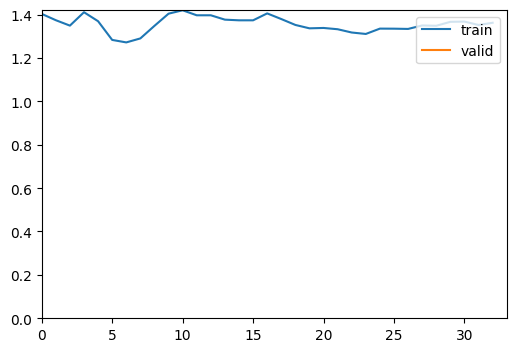

epoch,train_loss,valid_loss,f1_score,time
0,1.055927,1.015146,0.668657,00:27
1,1.078538,0.914750,0.631206,00:26
2,1.058010,1.014649,0.645768,00:26
3,1.033039,0.902225,0.597122,00:29
4,1.004155,0.980741,0.558140,00:26


Better model found at epoch 0 with valid_loss value: 1.0151458978652954.


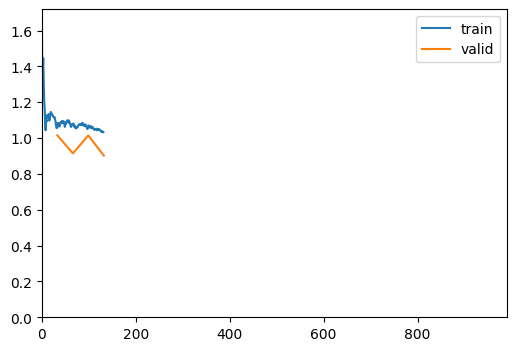

Better model found at epoch 1 with valid_loss value: 0.914750337600708.
Better model found at epoch 3 with valid_loss value: 0.9022251963615417.
No improvement since epoch 0: early stopping


In [88]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

dls = db.dataloaders(p_under2, bs=32)

callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=4),
    SaveModelCallback(fname='modelResnet50')
]

learn = vision_learner(dls, resnet50, metrics=F1Score(), cbs=callbacks).to_fp16()
learn.fine_tune(30, base_lr=1e-3)

In [89]:
learn.model[1] = learn.model[1][:-4]

caracteristicas_train = []
with torch.no_grad():
    for images, labels in dls[0]:
        outputs = learn.model(images)
        caracteristicas_train.extend(outputs)

caracteristicas_test = []
with torch.no_grad():
    for images, labels in dls[1]:
        outputs = learn.model(images)
        caracteristicas_test.extend(outputs)

img_train, img_test = db.splitter(db.get_items(p_under2))

In [90]:
dftrain = creaDF(img_train, caracteristicas_train, dfb2)
dftrain.columns = dftrain.columns.astype(str)
dftest = creaDF(img_test, caracteristicas_test, dfb2)
dftest.columns = dftest.columns.astype(str)

X_train = dftrain.drop(["cancer"], axis=1).copy()
y_train = dftrain.loc[::, "cancer"].copy()

X_test = dftest.drop(["cancer"], axis=1).copy()
y_test = dftest.loc[::, "cancer"].copy()

#### Segundo paso

In [91]:
arbolC45 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores1 =  model_selection.GridSearchCV(arbolC45, param_grid, scoring = 'accuracy')
clasificadores1.fit(X_train, y_train.values.ravel())
mejorConfiguracion1 = clasificadores1.best_params_
accTrain = round(metrics.accuracy_score(clasificadores1.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores1.predict(X_test), y_test) * 100, 2)
mejorConfiguracion1, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 2}, 71.21, 64.39)

In [92]:
arbolCART = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores2 =  model_selection.GridSearchCV(arbolCART, param_grid, scoring = 'accuracy')
clasificadores2.fit(X_train, y_train.values.ravel())
mejorConfiguracion2 = clasificadores2.best_params_
accTrain = round(metrics.accuracy_score(clasificadores2.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores2.predict(X_test), y_test) * 100, 2)
mejorConfiguracion2, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 20}, 73.58, 61.74)

In [93]:
regresionLogistica = LogisticRegression()
param_grid = {'C': [0.001, 0.01, 0.1, 1]}
clasificadores3 =  model_selection.GridSearchCV(regresionLogistica, param_grid, scoring = 'accuracy')
clasificadores3.fit(X_train, y_train.values.ravel())
mejorConfiguracion3 = clasificadores3.best_params_
accTrain = round(metrics.accuracy_score(clasificadores3.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores3.predict(X_test), y_test) * 100, 2)
mejorConfiguracion3, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

({'C': 0.001}, 74.05, 62.5)

In [94]:
redNeuronal = MLPClassifier(random_state = 0)
param_grid = {'hidden_layer_sizes': [10, 25, 50, 100], 'alpha': [0.0001, 0.001, 0.01, 0.1]}
clasificadores4 =  model_selection.GridSearchCV(redNeuronal, param_grid, scoring = 'accuracy')
clasificadores4.fit(X_train, y_train.values.ravel())
mejorConfiguracion4 = clasificadores4.best_params_
accTrain = round(metrics.accuracy_score(clasificadores4.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores4.predict(X_test), y_test) * 100, 2)
mejorConfiguracion4, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

({'alpha': 0.001, 'hidden_layer_sizes': 50}, 100.0, 53.41)

In [95]:
SVM = SVC(gamma = "auto", random_state = 0)
param_grid = {'decision_function_shape': ['ovo', 'ovr']}
clasificadores5 =  model_selection.GridSearchCV(SVM, param_grid, scoring = 'accuracy')
clasificadores5.fit(X_train, y_train.values.ravel())
mejorConfiguracion5 = clasificadores5.best_params_
accTrain = round(metrics.accuracy_score(clasificadores5.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores5.predict(X_test), y_test) * 100, 2)
mejorConfiguracion5, accTrain, accTest

({'decision_function_shape': 'ovo'}, 100.0, 61.36)

In [96]:
rf = RandomForestClassifier(random_state = 0)
param_grid = {'criterion':["gini", "entropy"],'max_features':["sqrt", "log2", None], 'bootstrap': [True, False]}
clasificadores6 =  model_selection.GridSearchCV(rf, param_grid, scoring = 'accuracy')
clasificadores6.fit(X_train, y_train.values.ravel())
mejorConfiguracion6 = clasificadores6.best_params_
accTrain = round(metrics.accuracy_score(clasificadores6.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores6.predict(X_test), y_test) * 100, 2)
mejorConfiguracion6, accTrain, accTest

({'bootstrap': True, 'criterion': 'entropy', 'max_features': None},
 100.0,
 63.26)

In [97]:
mostrar_resultados("Árbol de Decisión C4.5", clasificadores1, X_test, y_test)
mostrar_resultados("Árbol de Decisión CART", clasificadores2, X_test, y_test)
mostrar_resultados("Regresión logística", clasificadores3, X_test, y_test)
mostrar_resultados("Red neuronal", clasificadores4, X_test, y_test)
mostrar_resultados("SVM", clasificadores5, X_test, y_test)
mostrar_resultados("Random Forest", clasificadores6, X_test, y_test)

>  Árbol de Decisión C4.5
>  Accuracy: 64.39

[[0.32954545 0.17045455]
 [0.18560606 0.31439394]]
0.6384615384615384
>  Árbol de Decisión CART
>  Accuracy: 61.74

[[0.32954545 0.17045455]
 [0.21212121 0.28787879]]
0.6007905138339921
>  Regresión logística
>  Accuracy: 62.5

[[0.33712121 0.16287879]
 [0.21212121 0.28787879]]
0.605577689243028
>  Red neuronal
>  Accuracy: 53.41

[[0.36742424 0.13257576]
 [0.33333333 0.16666667]]
0.41706161137440756
>  SVM
>  Accuracy: 61.36

[[0.25       0.25      ]
 [0.13636364 0.36363636]]
0.6530612244897959
>  Random Forest
>  Accuracy: 63.26

[[0.30681818 0.19318182]
 [0.17424242 0.32575758]]
0.6394052044609665


### EfficientNet

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-cf984f9c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-cf984f9c.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 82.8MB/s]


epoch,train_loss,valid_loss,f1_score,time
0,1.330620,nan,0.349515,00:28


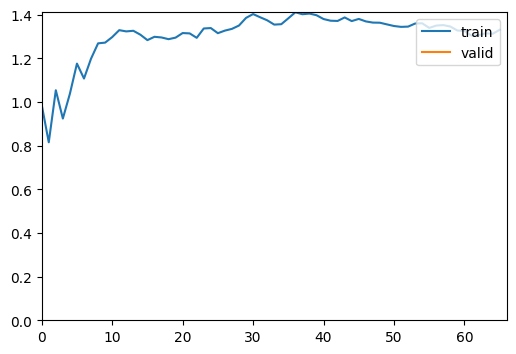

FileNotFoundError: ignored

In [98]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

dls = db.dataloaders(p_under2, bs=16)

callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=4),
    SaveModelCallback(fname='efficientNetB3')
]

learn = vision_learner(dls, efficientnet_b3, metrics=F1Score(), cbs=callbacks).to_fp16()
learn.fine_tune(30, base_lr=1e-5)

In [99]:
learn.model[1] = learn.model[1][:-4]

caracteristicas_train = []
with torch.no_grad():
    for images, labels in dls[0]:
        outputs = learn.model(images)
        caracteristicas_train.extend(outputs)

caracteristicas_test = []
with torch.no_grad():
    for images, labels in dls[1]:
        outputs = learn.model(images)
        caracteristicas_test.extend(outputs)

img_train, img_test = db.splitter(db.get_items(p_under2))

In [100]:
dftrain = creaDF(img_train, caracteristicas_train, dfb2)
dftrain.columns = dftrain.columns.astype(str)
dftest = creaDF(img_test, caracteristicas_test, dfb2)
dftest.columns = dftest.columns.astype(str)

X_train = dftrain.drop(["cancer"], axis=1).copy()
y_train = dftrain.loc[::, "cancer"].copy()

X_test = dftest.drop(["cancer"], axis=1).copy()
y_test = dftest.loc[::, "cancer"].copy()

#### Segundo paso

In [101]:
arbolC45 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores1 =  model_selection.GridSearchCV(arbolC45, param_grid, scoring = 'accuracy')
clasificadores1.fit(X_train, y_train.values.ravel())
mejorConfiguracion1 = clasificadores1.best_params_
accTrain = round(metrics.accuracy_score(clasificadores1.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores1.predict(X_test), y_test) * 100, 2)
mejorConfiguracion1, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 20}, 71.02, 54.92)

In [102]:
arbolCART = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores2 =  model_selection.GridSearchCV(arbolCART, param_grid, scoring = 'accuracy')
clasificadores2.fit(X_train, y_train.values.ravel())
mejorConfiguracion2 = clasificadores2.best_params_
accTrain = round(metrics.accuracy_score(clasificadores2.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores2.predict(X_test), y_test) * 100, 2)
mejorConfiguracion2, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 2}, 73.2, 54.92)

In [103]:
regresionLogistica = LogisticRegression()
param_grid = {'C': [0.001, 0.01, 0.1, 1]}
clasificadores3 =  model_selection.GridSearchCV(regresionLogistica, param_grid, scoring = 'accuracy')
clasificadores3.fit(X_train, y_train.values.ravel())
mejorConfiguracion3 = clasificadores3.best_params_
accTrain = round(metrics.accuracy_score(clasificadores3.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores3.predict(X_test), y_test) * 100, 2)
mejorConfiguracion3, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

({'C': 0.001}, 72.82, 59.85)

In [104]:
redNeuronal = MLPClassifier(random_state = 0)
param_grid = {'hidden_layer_sizes': [10, 25, 50, 100], 'alpha': [0.0001, 0.001, 0.01, 0.1]}
clasificadores4 =  model_selection.GridSearchCV(redNeuronal, param_grid, scoring = 'accuracy')
clasificadores4.fit(X_train, y_train.values.ravel())
mejorConfiguracion4 = clasificadores4.best_params_
accTrain = round(metrics.accuracy_score(clasificadores4.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores4.predict(X_test), y_test) * 100, 2)
mejorConfiguracion4, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

({'alpha': 0.01, 'hidden_layer_sizes': 10}, 99.81, 49.62)

In [105]:
SVM = SVC(gamma = "auto", random_state = 0)
param_grid = {'decision_function_shape': ['ovo', 'ovr']}
clasificadores5 =  model_selection.GridSearchCV(SVM, param_grid, scoring = 'accuracy')
clasificadores5.fit(X_train, y_train.values.ravel())
mejorConfiguracion5 = clasificadores5.best_params_
accTrain = round(metrics.accuracy_score(clasificadores5.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores5.predict(X_test), y_test) * 100, 2)
mejorConfiguracion5, accTrain, accTest

({'decision_function_shape': 'ovo'}, 100.0, 55.3)

In [106]:
rf = RandomForestClassifier(random_state = 0)
param_grid = {'criterion':["gini", "entropy"],'max_features':["sqrt", "log2", None], 'bootstrap': [True, False]}
clasificadores6 =  model_selection.GridSearchCV(rf, param_grid, scoring = 'accuracy')
clasificadores6.fit(X_train, y_train.values.ravel())
mejorConfiguracion6 = clasificadores6.best_params_
accTrain = round(metrics.accuracy_score(clasificadores6.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores6.predict(X_test), y_test) * 100, 2)
mejorConfiguracion6, accTrain, accTest

({'bootstrap': True, 'criterion': 'entropy', 'max_features': None},
 100.0,
 56.06)

In [107]:
mostrar_resultados("Árbol de Decisión C4.5", clasificadores1, X_test, y_test)
mostrar_resultados("Árbol de Decisión CART", clasificadores2, X_test, y_test)
mostrar_resultados("Regresión logística", clasificadores3, X_test, y_test)
mostrar_resultados("Red neuronal", clasificadores4, X_test, y_test)
mostrar_resultados("SVM", clasificadores5, X_test, y_test)
mostrar_resultados("Random Forest", clasificadores6, X_test, y_test)

>  Árbol de Decisión C4.5
>  Accuracy: 54.92

[[0.20454545 0.29545455]
 [0.15530303 0.34469697]]
0.6046511627906977
>  Árbol de Decisión CART
>  Accuracy: 54.92

[[0.25       0.25      ]
 [0.20075758 0.29924242]]
0.5703971119133573
>  Regresión logística
>  Accuracy: 59.85

[[0.28030303 0.21969697]
 [0.18181818 0.31818182]]
0.6131386861313868
>  Red neuronal
>  Accuracy: 49.62

[[0.35227273 0.14772727]
 [0.35606061 0.14393939]]
0.3636363636363637
>  SVM
>  Accuracy: 55.3

[[0.09848485 0.40151515]
 [0.04545455 0.45454545]]
0.670391061452514
>  Random Forest
>  Accuracy: 56.06

[[0.18560606 0.31439394]
 [0.125      0.375     ]]
0.6305732484076434


### ConvNext

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:05<00:00, 67.9MB/s]


epoch,train_loss,valid_loss,f1_score,time
0,1.372954,1.119494,0.393782,00:53


Better model found at epoch 0 with valid_loss value: 1.119493842124939.


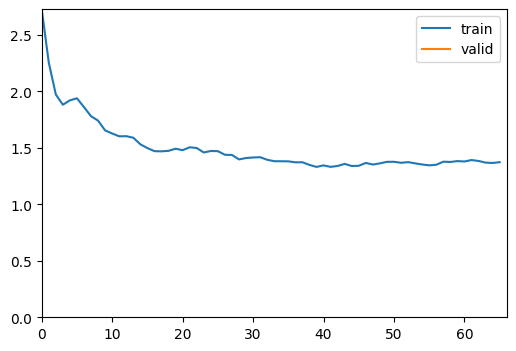

epoch,train_loss,valid_loss,f1_score,time
0,1.093373,1.295102,0.239521,01:09
1,1.070255,1.134696,0.320442,01:10
2,1.070818,1.060139,0.404145,01:10
3,0.995008,1.268070,0.175000,01:10
4,0.985626,1.055742,0.292135,01:10
5,0.941514,0.984470,0.340659,01:10


Better model found at epoch 0 with valid_loss value: 1.2951017618179321.


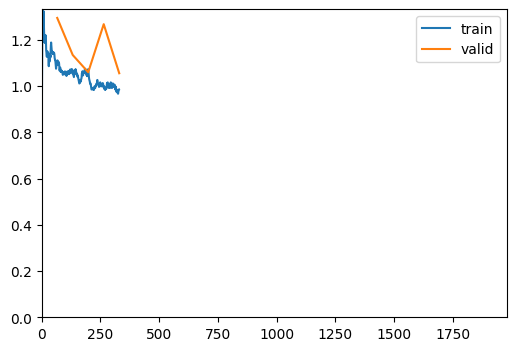

Better model found at epoch 1 with valid_loss value: 1.134696364402771.
Better model found at epoch 2 with valid_loss value: 1.0601389408111572.
Better model found at epoch 4 with valid_loss value: 1.0557416677474976.
Better model found at epoch 5 with valid_loss value: 0.9844703674316406.
No improvement since epoch 2: early stopping


In [108]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

dls = db.dataloaders(p_under2, bs=16)

callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='ConvNext')
]

learn = vision_learner(dls, convnext_base, metrics=F1Score(), cbs=callbacks).to_fp16()
learn.fine_tune(30, base_lr=1e-3)

In [109]:
learn.model[1] = learn.model[1][:-4]

caracteristicas_train = []
with torch.no_grad():
    for images, labels in dls[0]:
        outputs = learn.model(images)
        caracteristicas_train.extend(outputs)

caracteristicas_test = []
with torch.no_grad():
    for images, labels in dls[1]:
        outputs = learn.model(images)
        caracteristicas_test.extend(outputs)

img_train, img_test = db.splitter(db.get_items(p_under2))

In [110]:
dftrain = creaDF(img_train, caracteristicas_train, dfb2)
dftrain.columns = dftrain.columns.astype(str)
dftest = creaDF(img_test, caracteristicas_test, dfb2)
dftest.columns = dftest.columns.astype(str)

X_train = dftrain.drop(["cancer"], axis=1).copy()
y_train = dftrain.loc[::, "cancer"].copy()

X_test = dftest.drop(["cancer"], axis=1).copy()
y_test = dftest.loc[::, "cancer"].copy()

#### Segundo paso

In [111]:
arbolC45 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores1 =  model_selection.GridSearchCV(arbolC45, param_grid, scoring = 'accuracy')
clasificadores1.fit(X_train, y_train.values.ravel())
mejorConfiguracion1 = clasificadores1.best_params_
accTrain = round(metrics.accuracy_score(clasificadores1.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores1.predict(X_test), y_test) * 100, 2)
mejorConfiguracion1, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 2}, 70.17, 59.47)

In [112]:
arbolCART = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores2 =  model_selection.GridSearchCV(arbolCART, param_grid, scoring = 'accuracy')
clasificadores2.fit(X_train, y_train.values.ravel())
mejorConfiguracion2 = clasificadores2.best_params_
accTrain = round(metrics.accuracy_score(clasificadores2.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores2.predict(X_test), y_test) * 100, 2)
mejorConfiguracion2, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 2}, 76.23, 57.58)

In [113]:
regresionLogistica = LogisticRegression()
param_grid = {'C': [0.001, 0.01, 0.1, 1]}
clasificadores3 =  model_selection.GridSearchCV(regresionLogistica, param_grid, scoring = 'accuracy')
clasificadores3.fit(X_train, y_train.values.ravel())
mejorConfiguracion3 = clasificadores3.best_params_
accTrain = round(metrics.accuracy_score(clasificadores3.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores3.predict(X_test), y_test) * 100, 2)
mejorConfiguracion3, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

({'C': 0.001}, 71.12, 63.64)

In [114]:
redNeuronal = MLPClassifier(random_state = 0)
param_grid = {'hidden_layer_sizes': [10, 25, 50, 100], 'alpha': [0.0001, 0.001, 0.01, 0.1]}
clasificadores4 =  model_selection.GridSearchCV(redNeuronal, param_grid, scoring = 'accuracy')
clasificadores4.fit(X_train, y_train.values.ravel())
mejorConfiguracion4 = clasificadores4.best_params_
accTrain = round(metrics.accuracy_score(clasificadores4.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores4.predict(X_test), y_test) * 100, 2)
mejorConfiguracion4, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

({'alpha': 0.0001, 'hidden_layer_sizes': 100}, 100.0, 49.24)

In [115]:
SVM = SVC(gamma = "auto", random_state = 0)
param_grid = {'decision_function_shape': ['ovo', 'ovr']}
clasificadores5 =  model_selection.GridSearchCV(SVM, param_grid, scoring = 'accuracy')
clasificadores5.fit(X_train, y_train.values.ravel())
mejorConfiguracion5 = clasificadores5.best_params_
accTrain = round(metrics.accuracy_score(clasificadores5.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores5.predict(X_test), y_test) * 100, 2)
mejorConfiguracion5, accTrain, accTest

({'decision_function_shape': 'ovo'}, 99.24, 62.88)

In [116]:
rf = RandomForestClassifier(random_state = 0)
param_grid = {'criterion':["gini", "entropy"],'max_features':["sqrt", "log2", None], 'bootstrap': [True, False]}
clasificadores6 =  model_selection.GridSearchCV(rf, param_grid, scoring = 'accuracy')
clasificadores6.fit(X_train, y_train.values.ravel())
mejorConfiguracion6 = clasificadores6.best_params_
accTrain = round(metrics.accuracy_score(clasificadores6.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores6.predict(X_test), y_test) * 100, 2)
mejorConfiguracion6, accTrain, accTest

({'bootstrap': True, 'criterion': 'gini', 'max_features': None}, 100.0, 64.39)

In [117]:
mostrar_resultados("Árbol de Decisión C4.5", clasificadores1, X_test, y_test)
mostrar_resultados("Árbol de Decisión CART", clasificadores2, X_test, y_test)
mostrar_resultados("Regresión logística", clasificadores3, X_test, y_test)
mostrar_resultados("Red neuronal", clasificadores4, X_test, y_test)
mostrar_resultados("SVM", clasificadores5, X_test, y_test)
mostrar_resultados("Random Forest", clasificadores6, X_test, y_test)

>  Árbol de Decisión C4.5
>  Accuracy: 59.47

[[0.21590909 0.28409091]
 [0.12121212 0.37878788]]
0.6514657980456027
>  Árbol de Decisión CART
>  Accuracy: 57.58

[[0.28030303 0.21969697]
 [0.20454545 0.29545455]]
0.5820895522388059
>  Regresión logística
>  Accuracy: 63.64

[[0.31818182 0.18181818]
 [0.18181818 0.31818182]]
0.6363636363636364
>  Red neuronal
>  Accuracy: 49.24

[[0.20833333 0.29166667]
 [0.21590909 0.28409091]]
0.5281690140845071
>  SVM
>  Accuracy: 62.88

[[0.28030303 0.21969697]
 [0.15151515 0.34848485]]
0.652482269503546
>  Random Forest
>  Accuracy: 64.39

[[0.3030303  0.1969697 ]
 [0.15909091 0.34090909]]
0.6569343065693432


### Hrnet

epoch,train_loss,valid_loss,f1_score,time
0,1.330634,1.273350,0.567050,01:21


Better model found at epoch 0 with valid_loss value: 1.2733498811721802.


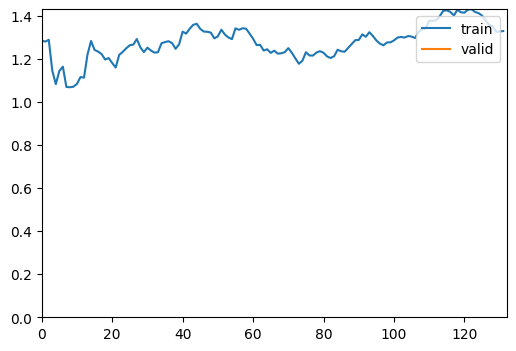

epoch,train_loss,valid_loss,f1_score,time
0,1.136142,0.923650,0.546154,01:48
1,1.078489,0.867942,0.528736,01:49
2,1.049048,0.804974,0.628763,01:49
3,1.029541,0.831881,0.583893,01:49
4,0.931335,0.798580,0.638806,01:49
5,0.911452,0.848415,0.587838,01:49
6,0.833029,0.875889,0.622642,01:49
7,0.845935,0.757167,0.655844,01:54
8,0.792221,0.719504,0.678363,01:51
9,0.776330,0.784627,0.616438,01:50


Better model found at epoch 0 with valid_loss value: 0.9236497282981873.


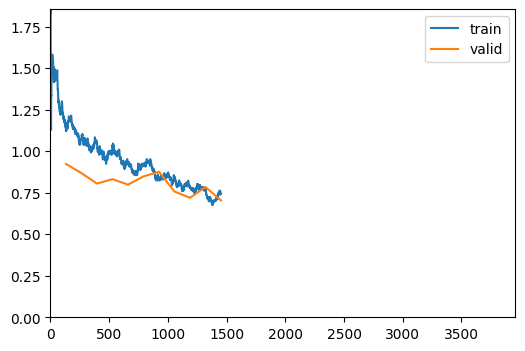

Better model found at epoch 1 with valid_loss value: 0.8679418563842773.
Better model found at epoch 2 with valid_loss value: 0.8049741983413696.
Better model found at epoch 4 with valid_loss value: 0.7985803484916687.
Better model found at epoch 7 with valid_loss value: 0.7571670413017273.
Better model found at epoch 8 with valid_loss value: 0.7195035219192505.
Better model found at epoch 10 with valid_loss value: 0.7033779621124268.
No improvement since epoch 8: early stopping


In [118]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

dls = db.dataloaders(p_under2, bs=8)

callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Hrnet')
]

learn = vision_learner(dls, 'hrnet_w44', metrics=F1Score(), cbs=callbacks).to_fp16()
learn.fine_tune(30, base_lr=1e-3)

In [119]:
learn.model[1] = learn.model[1][:-4]

caracteristicas_train = []
with torch.no_grad():
    for images, labels in dls[0]:
        outputs = learn.model(images)
        caracteristicas_train.extend(outputs)

caracteristicas_test = []
with torch.no_grad():
    for images, labels in dls[1]:
        outputs = learn.model(images)
        caracteristicas_test.extend(outputs)

img_train, img_test = db.splitter(db.get_items(p_under2))

In [120]:
dftrain = creaDF(img_train, caracteristicas_train, dfb2)
dftrain.columns = dftrain.columns.astype(str)
dftest = creaDF(img_test, caracteristicas_test, dfb2)
dftest.columns = dftest.columns.astype(str)

X_train = dftrain.drop(["cancer"], axis=1).copy()
y_train = dftrain.loc[::, "cancer"].copy()

X_test = dftest.drop(["cancer"], axis=1).copy()
y_test = dftest.loc[::, "cancer"].copy()

#### Segundo paso

In [121]:
arbolC45 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores1 =  model_selection.GridSearchCV(arbolC45, param_grid, scoring = 'accuracy')
clasificadores1.fit(X_train, y_train.values.ravel())
mejorConfiguracion1 = clasificadores1.best_params_
accTrain = round(metrics.accuracy_score(clasificadores1.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores1.predict(X_test), y_test) * 100, 2)
mejorConfiguracion1, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 2}, 72.16, 59.09)

In [122]:
arbolCART = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores2 =  model_selection.GridSearchCV(arbolCART, param_grid, scoring = 'accuracy')
clasificadores2.fit(X_train, y_train.values.ravel())
mejorConfiguracion2 = clasificadores2.best_params_
accTrain = round(metrics.accuracy_score(clasificadores2.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores2.predict(X_test), y_test) * 100, 2)
mejorConfiguracion2, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 10}, 74.34, 65.15)

In [123]:
regresionLogistica = LogisticRegression()
param_grid = {'C': [0.001, 0.01, 0.1, 1]}
clasificadores3 =  model_selection.GridSearchCV(regresionLogistica, param_grid, scoring = 'accuracy')
clasificadores3.fit(X_train, y_train.values.ravel())
mejorConfiguracion3 = clasificadores3.best_params_
accTrain = round(metrics.accuracy_score(clasificadores3.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores3.predict(X_test), y_test) * 100, 2)
mejorConfiguracion3, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

({'C': 1}, 79.07, 53.03)

In [124]:
redNeuronal = MLPClassifier(random_state = 0)
param_grid = {'hidden_layer_sizes': [10, 25, 50, 100], 'alpha': [0.0001, 0.001, 0.01, 0.1]}
clasificadores4 =  model_selection.GridSearchCV(redNeuronal, param_grid, scoring = 'accuracy')
clasificadores4.fit(X_train, y_train.values.ravel())
mejorConfiguracion4 = clasificadores4.best_params_
accTrain = round(metrics.accuracy_score(clasificadores4.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores4.predict(X_test), y_test) * 100, 2)
mejorConfiguracion4, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


({'alpha': 0.0001, 'hidden_layer_sizes': 25}, 78.12, 56.06)

In [125]:
SVM = SVC(gamma = "auto", random_state = 0)
param_grid = {'decision_function_shape': ['ovo', 'ovr']}
clasificadores5 =  model_selection.GridSearchCV(SVM, param_grid, scoring = 'accuracy')
clasificadores5.fit(X_train, y_train.values.ravel())
mejorConfiguracion5 = clasificadores5.best_params_
accTrain = round(metrics.accuracy_score(clasificadores5.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores5.predict(X_test), y_test) * 100, 2)
mejorConfiguracion5, accTrain, accTest

({'decision_function_shape': 'ovo'}, 100.0, 52.65)

In [126]:
rf = RandomForestClassifier(random_state = 0)
param_grid = {'criterion':["gini", "entropy"],'max_features':["sqrt", "log2", None], 'bootstrap': [True, False]}
clasificadores6 =  model_selection.GridSearchCV(rf, param_grid, scoring = 'accuracy')
clasificadores6.fit(X_train, y_train.values.ravel())
mejorConfiguracion6 = clasificadores6.best_params_
accTrain = round(metrics.accuracy_score(clasificadores6.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores6.predict(X_test), y_test) * 100, 2)
mejorConfiguracion6, accTrain, accTest

({'bootstrap': True, 'criterion': 'entropy', 'max_features': None},
 100.0,
 66.67)

In [127]:
mostrar_resultados("Árbol de Decisión C4.5", clasificadores1, X_test, y_test)
mostrar_resultados("Árbol de Decisión CART", clasificadores2, X_test, y_test)
mostrar_resultados("Regresión logística", clasificadores3, X_test, y_test)
mostrar_resultados("Red neuronal", clasificadores4, X_test, y_test)
mostrar_resultados("SVM", clasificadores5, X_test, y_test)
mostrar_resultados("Random Forest", clasificadores6, X_test, y_test)

>  Árbol de Decisión C4.5
>  Accuracy: 59.09

[[0.23863636 0.26136364]
 [0.14772727 0.35227273]]
0.6326530612244898
>  Árbol de Decisión CART
>  Accuracy: 65.15

[[0.38636364 0.11363636]
 [0.23484848 0.26515152]]
0.603448275862069
>  Regresión logística
>  Accuracy: 53.03

[[0.18939394 0.31060606]
 [0.15909091 0.34090909]]
0.5921052631578948
>  Red neuronal
>  Accuracy: 56.06

[[0.20454545 0.29545455]
 [0.14393939 0.35606061]]
0.618421052631579
>  SVM
>  Accuracy: 52.65

[[0.03787879 0.46212121]
 [0.01136364 0.48863636]]
0.6736292428198434
>  Random Forest
>  Accuracy: 66.67

[[0.31439394 0.18560606]
 [0.14772727 0.35227273]]
0.6788321167883212


### Deit

epoch,train_loss,valid_loss,f1_score,time
0,1.194950,0.902323,0.597015,00:31


Better model found at epoch 0 with valid_loss value: 0.9023230075836182.


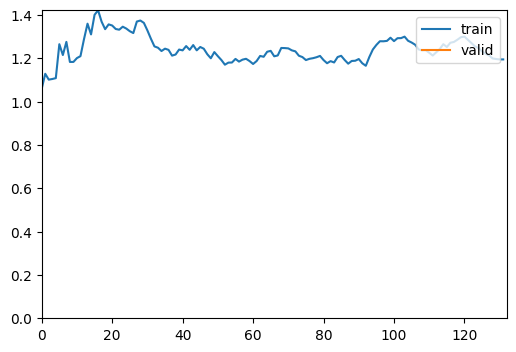

epoch,train_loss,valid_loss,f1_score,time
0,1.064313,0.789138,0.617647,00:42
1,0.935813,0.779414,0.636015,00:42
2,0.956474,0.784775,0.558704,00:41
3,0.920847,0.712800,0.674074,00:41
4,0.816733,0.797954,0.611765,00:41
5,0.809422,0.792525,0.621723,00:41
6,0.794199,0.791596,0.631970,00:41


Better model found at epoch 0 with valid_loss value: 0.7891384959220886.


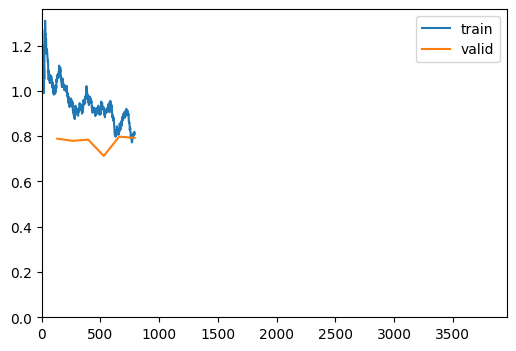

Better model found at epoch 1 with valid_loss value: 0.7794135212898254.
Better model found at epoch 3 with valid_loss value: 0.7128002047538757.
No improvement since epoch 3: early stopping


In [128]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=384,min_scale=0.75))

dls = db.dataloaders(p_under2, bs=8)

callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Deit')
]

learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=F1Score(), cbs=callbacks).to_fp16()
learn.fine_tune(30, base_lr=1e-3)

In [129]:
learn.model[1] = learn.model[1][:-2]

caracteristicas_train = []
with torch.no_grad():
    for images, labels in dls[0]:
        outputs = learn.model(images)
        caracteristicas_train.extend(outputs)

caracteristicas_test = []
with torch.no_grad():
    for images, labels in dls[1]:
        outputs = learn.model(images)
        caracteristicas_test.extend(outputs)

img_train, img_test = db.splitter(db.get_items(p_under2))

In [130]:
dftrain = creaDF(img_train, caracteristicas_train, dfb2)
dftrain.columns = dftrain.columns.astype(str)
dftest = creaDF(img_test, caracteristicas_test, dfb2)
dftest.columns = dftest.columns.astype(str)

X_train = dftrain.drop(["cancer"], axis=1).copy()
y_train = dftrain.loc[::, "cancer"].copy()

X_test = dftest.drop(["cancer"], axis=1).copy()
y_test = dftest.loc[::, "cancer"].copy()

#### Segundo paso

In [131]:
arbolC45 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores1 =  model_selection.GridSearchCV(arbolC45, param_grid, scoring = 'accuracy')
clasificadores1.fit(X_train, y_train.values.ravel())
mejorConfiguracion1 = clasificadores1.best_params_
accTrain = round(metrics.accuracy_score(clasificadores1.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores1.predict(X_test), y_test) * 100, 2)
mejorConfiguracion1, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 10}, 72.35, 62.5)

In [132]:
arbolCART = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores2 =  model_selection.GridSearchCV(arbolCART, param_grid, scoring = 'accuracy')
clasificadores2.fit(X_train, y_train.values.ravel())
mejorConfiguracion2 = clasificadores2.best_params_
accTrain = round(metrics.accuracy_score(clasificadores2.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores2.predict(X_test), y_test) * 100, 2)
mejorConfiguracion2, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 2}, 72.54, 58.33)

In [133]:
regresionLogistica = LogisticRegression()
param_grid = {'C': [0.001, 0.01, 0.1, 1]}
clasificadores3 =  model_selection.GridSearchCV(regresionLogistica, param_grid, scoring = 'accuracy')
clasificadores3.fit(X_train, y_train.values.ravel())
mejorConfiguracion3 = clasificadores3.best_params_
accTrain = round(metrics.accuracy_score(clasificadores3.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores3.predict(X_test), y_test) * 100, 2)
mejorConfiguracion3, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

({'C': 0.001}, 68.47, 64.77)

In [134]:
redNeuronal = MLPClassifier(random_state = 0)
param_grid = {'hidden_layer_sizes': [10, 25, 50, 100], 'alpha': [0.0001, 0.001, 0.01, 0.1]}
clasificadores4 =  model_selection.GridSearchCV(redNeuronal, param_grid, scoring = 'accuracy')
clasificadores4.fit(X_train, y_train.values.ravel())
mejorConfiguracion4 = clasificadores4.best_params_
accTrain = round(metrics.accuracy_score(clasificadores4.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores4.predict(X_test), y_test) * 100, 2)
mejorConfiguracion4, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

({'alpha': 0.1, 'hidden_layer_sizes': 10}, 99.72, 54.92)

In [135]:
SVM = SVC(gamma = "auto", random_state = 0)
param_grid = {'decision_function_shape': ['ovo', 'ovr']}
clasificadores5 =  model_selection.GridSearchCV(SVM, param_grid, scoring = 'accuracy')
clasificadores5.fit(X_train, y_train.values.ravel())
mejorConfiguracion5 = clasificadores5.best_params_
accTrain = round(metrics.accuracy_score(clasificadores5.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores5.predict(X_test), y_test) * 100, 2)
mejorConfiguracion5, accTrain, accTest

({'decision_function_shape': 'ovo'}, 82.86, 64.39)

In [136]:
rf = RandomForestClassifier(random_state = 0)
param_grid = {'criterion':["gini", "entropy"],'max_features':["sqrt", "log2", None], 'bootstrap': [True, False]}
clasificadores6 =  model_selection.GridSearchCV(rf, param_grid, scoring = 'accuracy')
clasificadores6.fit(X_train, y_train.values.ravel())
mejorConfiguracion6 = clasificadores6.best_params_
accTrain = round(metrics.accuracy_score(clasificadores6.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores6.predict(X_test), y_test) * 100, 2)
mejorConfiguracion6, accTrain, accTest

({'bootstrap': True, 'criterion': 'entropy', 'max_features': None},
 100.0,
 62.5)

In [137]:
mostrar_resultados("Árbol de Decisión C4.5", clasificadores1, X_test, y_test)
mostrar_resultados("Árbol de Decisión CART", clasificadores2, X_test, y_test)
mostrar_resultados("Regresión logística", clasificadores3, X_test, y_test)
mostrar_resultados("Red neuronal", clasificadores4, X_test, y_test)
mostrar_resultados("SVM", clasificadores5, X_test, y_test)
mostrar_resultados("Random Forest", clasificadores6, X_test, y_test)

>  Árbol de Decisión C4.5
>  Accuracy: 62.5

[[0.37121212 0.12878788]
 [0.24621212 0.25378788]]
0.5751072961373391
>  Árbol de Decisión CART
>  Accuracy: 58.33

[[0.35984848 0.14015152]
 [0.27651515 0.22348485]]
0.5175438596491229
>  Regresión logística
>  Accuracy: 64.77

[[0.32954545 0.17045455]
 [0.18181818 0.31818182]]
0.6436781609195402
>  Red neuronal
>  Accuracy: 54.92

[[0.26515152 0.23484848]
 [0.21590909 0.28409091]]
0.5576208178438662
>  SVM
>  Accuracy: 64.39

[[0.32954545 0.17045455]
 [0.18560606 0.31439394]]
0.6384615384615384
>  Random Forest
>  Accuracy: 62.5

[[0.3219697 0.1780303]
 [0.1969697 0.3030303]]
0.6177606177606176
